# NB04 - Doppler Ground Truth Feature Extraction

This notebook converts quality-controlled Doppler ultrasound recordings into structured hemodynamic features for exploratory ground-truth generation.

The notebook builds on previous work:

- **NB01** - Doppler image waveform extraction
- **NB02** - Doppler audio extraction
- **NB03** - image-audio quality control and synchronization

NB04 does not modify the previous notebooks.  
NB01, NB02, and NB03 are treated as completed upstream modules.

## Main objective

The objective is to build beat-level and recording-level Doppler-derived feature tables from recordings that passed integrated multimodal QC.

The target outputs are:

- beat-level feature table
- recording-level summary table
- velocity calibration table
- morphology candidate table
- notebook dashboard plots
- CSV exports for future machine-learning experiments

## Imports and Setup

In [1]:
import cv2, json, subprocess, wave
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from scipy.signal import savgol_filter, find_peaks, medfilt, hilbert, welch, spectrogram
import soundfile as sf
from scipy.ndimage import uniform_filter1d

# Notebook display setup
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

In [2]:
# Project Paths

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"

VIDEO_DIR = PROJECT_ROOT / "ultrasound_recordings"
AUDIO_EXPORT_DIR = PROJECT_ROOT / "audio_exports"
FEATURE_EXPORT_DIR = PROJECT_ROOT / "feature_exports"
DASHBOARD_EXPORT_DIR = PROJECT_ROOT / "dashboard_exports"
CALIBRATION_FRAME_DIR = PROJECT_ROOT / "calibration_frames"


OUTPUT_DIRS = [
    AUDIO_EXPORT_DIR,
    FEATURE_EXPORT_DIR,
    DASHBOARD_EXPORT_DIR,
    CALIBRATION_FRAME_DIR,
]


for output_dir in OUTPUT_DIRS:
    output_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# Recording registry
recording_registry_df = pd.DataFrame(
    [
        {
            "recording_name": "candidate_long_quality_test",
            "qc_status_nb03": "PASS",
            "include_in_nb04": True,
            "video_path": VIDEO_DIR / "candidate_long_quality_test.avi",
            "audio_path": AUDIO_EXPORT_DIR / "candidate_long_quality_test_audio.wav",
        },
        {
            "recording_name": "candidate_2",
            "qc_status_nb03": "PASS",
            "include_in_nb04": True,
            "video_path": VIDEO_DIR / "candidate_2.avi",
            "audio_path": AUDIO_EXPORT_DIR / "candidate_2_audio.wav",
        },
        {
            "recording_name": "candidate_1",
            "qc_status_nb03": "FAIL",
            "include_in_nb04": False,
            "video_path": VIDEO_DIR / "candidate_1.avi",
            "audio_path": AUDIO_EXPORT_DIR / "candidate_1_audio.wav",
        },
        {
            "recording_name": "candidate_3",
            "qc_status_nb03": "FAIL",
            "include_in_nb04": False,
            "video_path": VIDEO_DIR / "candidate_3.avi",
            "audio_path": AUDIO_EXPORT_DIR / "candidate_3_audio.wav",
        },
    ]
)

recording_registry_df["video_found"] = recording_registry_df["video_path"].apply(lambda p: Path(p).exists())
recording_registry_df["audio_found"] = recording_registry_df["audio_path"].apply(lambda p: Path(p).exists())

In [4]:
# Output files
BEAT_FEATURES_CSV = FEATURE_EXPORT_DIR / "doppler_gt_beat_features.csv"
RECORDING_SUMMARY_CSV = FEATURE_EXPORT_DIR / "doppler_gt_recording_summary.csv"
VELOCITY_CALIBRATION_CSV = FEATURE_EXPORT_DIR / "doppler_velocity_calibration.csv"
IMAGE_MORPHOLOGY_CANDIDATES_CSV = FEATURE_EXPORT_DIR / "doppler_image_morphology_candidates.csv"
MATCHED_CANDIDATES_CSV = FEATURE_EXPORT_DIR / "doppler_matched_candidates.csv"
NB04_QC_REPORT_CSV = FEATURE_EXPORT_DIR / "doppler_nb04_qc_report.csv"

In [5]:
# Simple media sanity check
media_rows = []

for _, row in recording_registry_df.iterrows():
    video_path = Path(row["video_path"])
    audio_path = Path(row["audio_path"])

    video_fps = np.nan
    video_frame_count = np.nan
    video_duration_s = np.nan
    video_width_px = np.nan
    video_height_px = np.nan

    if video_path.exists():
        cap = cv2.VideoCapture(str(video_path))
        video_fps = cap.get(cv2.CAP_PROP_FPS)
        video_frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        video_width_px = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        video_height_px = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        cap.release()

        if video_fps > 0:
            video_duration_s = video_frame_count / video_fps

    audio_sample_rate_hz = np.nan
    audio_n_channels = np.nan
    audio_n_samples = np.nan
    audio_duration_s = np.nan

    if audio_path.exists():
        with wave.open(str(audio_path), "rb") as wav_file:
            audio_sample_rate_hz = wav_file.getframerate()
            audio_n_channels = wav_file.getnchannels()
            audio_n_samples = wav_file.getnframes()
            audio_duration_s = audio_n_samples / audio_sample_rate_hz

    media_rows.append(
        {
            "recording_name" : row["recording_name"],
            "qc_status_nb03" : row["qc_status_nb03"],
            "include_in_nb04" : row["include_in_nb04"],
            "video_found" : row["video_found"],
            "audio_found" : row["audio_found"],
            "video_fps" : video_fps,
            "video_frame_count" : video_frame_count,
            "video_duration_s" : video_duration_s,
            "audio_duration_s" : audio_duration_s,
            "audio_minus_video_duration_s" : audio_duration_s - video_duration_s,
            "video_width_px" : video_width_px,
            "video_height_px" : video_height_px,
            "audio_sample_rate_hz" : audio_sample_rate_hz,
            "audio_n_channels" : audio_n_channels,
        }
    )

media_metadata_df = pd.DataFrame(media_rows)


print("NB04 setup summary")
print("=" * 80)
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"VIDEO_DIR: {VIDEO_DIR}")
print(f"AUDIO_EXPORT_DIR: {AUDIO_EXPORT_DIR}")
print(f"FEATURE_EXPORT_DIR: {FEATURE_EXPORT_DIR}")
print()

display(recording_registry_df)

print("Media sanity check")
print("=" * 80)
display(media_metadata_df)

NB04 setup summary
Timestamp: 2026-06-10 12:51:31
PROJECT_ROOT: D:\code\DopplerLab
VIDEO_DIR: D:\code\DopplerLab\ultrasound_recordings
AUDIO_EXPORT_DIR: D:\code\DopplerLab\audio_exports
FEATURE_EXPORT_DIR: D:\code\DopplerLab\feature_exports



,recording_name,qc_status_nb03,include_in_nb04,video_path,audio_path,video_found,audio_found
0,candidate_long_quality_test,PASS,True,D:\code\DopplerLab\ultrasound_recordings\candi...,D:\code\DopplerLab\audio_exports\candidate_lon...,True,True
1,candidate_2,PASS,True,D:\code\DopplerLab\ultrasound_recordings\candi...,D:\code\DopplerLab\audio_exports\candidate_2_a...,True,True
2,candidate_1,FAIL,False,D:\code\DopplerLab\ultrasound_recordings\candi...,D:\code\DopplerLab\audio_exports\candidate_1_a...,True,True
3,candidate_3,FAIL,False,D:\code\DopplerLab\ultrasound_recordings\candi...,D:\code\DopplerLab\audio_exports\candidate_3_a...,True,True


Media sanity check


,recording_name,qc_status_nb03,include_in_nb04,video_found,audio_found,video_fps,video_frame_count,video_duration_s,audio_duration_s,audio_minus_video_duration_s,video_width_px,video_height_px,audio_sample_rate_hz,audio_n_channels
0,candidate_long_quality_test,PASS,True,True,True,30.0,2295,76.500000,76.448000,-0.052000,720,540,96000,1
1,candidate_2,PASS,True,True,True,30.0,1028,34.266667,34.218667,-0.048000,720,540,96000,1
2,candidate_1,FAIL,False,True,True,30.0,1300,43.333333,43.296000,-0.037333,720,540,96000,1
3,candidate_3,FAIL,False,True,True,30.0,647,21.566667,21.525333,-0.041333,720,540,96000,1


# Copied upstream functions

NB04 is kept as a standalone research notebook.

Selected working functions from NB01, NB02, and NB03 are copied below so that this notebook can rebuild the required image, audio, QC, and synchronization context without relying on saved outputs from previous notebooks.

At this stage, code duplication is intentional.  
After the full NB04 pipeline works end-to-end, these functions can be moved into reusable modules, for example with nbdev.

---

## NB01 image functions

Core image extraction and morphology functions copied from NB01:

- `extract_envelope_directional`
- `extract_doppler_waveform`
- `analyze_beats`
- `compute_frame_quality_metrics`
- `apply_frame_quality_gate`
- `run_image_quality_scan_for_video`
- `summarize_frame_quality_segment`

Optional plotting/debug functions copied from NB01:

- `plot_doppler_extraction_result`
- `plot_beat_analysis`
- `plot_image_quality_scan`

---

## NB02 audio functions

Core audio extraction and QC functions copied from NB02:

- `inspect_media_streams`
- `extract_audio_to_wav`
- `load_audio`
- `compute_spectral_centroid`
- `detect_audio_beats`
- `build_audio_beat_table`
- `apply_audio_qc`
- `compute_band_energy`
- `detect_usable_audio_segment`
- `process_audio_recording_with_qc`

---

## NB03 image-audio QC and synchronization functions

Core multimodal QC and synchronization functions copied from NB03:

- `compare_usable_segments`
- `run_image_audio_qc_test_recording`
- `read_video_frame_at_time`
- `estimate_image_time_scale_from_audio_rr`
- `estimate_image_peak_times`
- `compare_image_peaks_to_nearest_audio_beats`
- `evaluate_offset_corrected_matching_across_frames`
- `build_sync_qc_feature_table`
- `apply_candidate_sync_qc_rule`
- `summarize_within_recording_time_scale_stability`
- `build_nb03_integrated_qc_report`

Optional plotting/debug functions copied from NB03:

- `plot_multimodal_qc_timeline`


### NB01 image functions

In [6]:
def extract_envelope_directional(mask, baseline, direction="auto", min_segment_length=5):
    """
    Extract the Doppler spectrum envelope from a binary mask.

    The envelope is detected relative to the Doppler baseline and can
    operate on spectra located either above or below the baseline.

    Returns the envelope position, velocity proxy, and the selected
    spectrum orientation.
    """

    if direction not in ["auto", "above", "below"]:
        raise ValueError("direction must be 'auto', 'above', or 'below'")
    if baseline <= 0 or baseline >= mask.shape[0] - 1:
        raise ValueError("Baseline is outside valid ROI range.")
    if min_segment_length < 1:
        raise ValueError("min_segment_length must be >= 1.")

    above_area = int(mask[:baseline, :].sum())
    below_area = int(mask[baseline + 1:, :].sum())

    if direction == "auto":
        selected_direction = "above" if above_area >= below_area else "below"
    else:
        selected_direction = direction

    envelope = np.full(mask.shape[1], np.nan)

    for x in range(mask.shape[1]):

        if selected_direction == "above":
            ys = np.where(mask[:baseline, x])[0]
        else:
            ys_local = np.where(mask[baseline + 1:, x])[0]
            ys = baseline + 1 + ys_local

        if len(ys) == 0:
            continue

        breaks = np.where(np.diff(ys) > 1)[0] + 1
        segments = np.split(ys, breaks)
        valid_segments = [segment for segment in segments if len(segment) >= min_segment_length]

        if len(valid_segments) == 0:
            continue
        if selected_direction == "above":
            envelope[x] = min(segment.min() for segment in valid_segments)
        else:
            envelope[x] = max(segment.max() for segment in valid_segments)

    if selected_direction == "above":
        velocity = baseline - envelope
    else:
        velocity = envelope - baseline

    return envelope, velocity, selected_direction

In [7]:
def extract_doppler_waveform(
    frame_rgb,
    x_min=80,
    x_max=640,
    y_min=230,
    y_max=510,
    threshold=80,
    direction="auto",
    min_segment_length=5,
    trim_left=10,
    trim_right=10,
    median_kernel_size=5,
    savgol_window_length=21,
    savgol_polyorder=3,
    peak_height=80,
    peak_distance=100,
):
    """
    Extract and smooth a Doppler waveform from a single RGB video frame.

    The function detects the Doppler baseline, extracts the spectrum envelope,
    trims edge artifacts, smooths the waveform, and detects PSV peaks.

    Returns a dictionary with intermediate outputs, waveform arrays, and
    local/global PSV peak positions.
    """
    roi = frame_rgb[y_min:y_max, x_min:x_max]
    gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
    mask = gray > threshold
    row_sums = mask.sum(axis=1)
    baseline = int(np.argmax(row_sums))

    envelope, velocity_raw, selected_direction = extract_envelope_directional(
        mask=mask,
        baseline=baseline,
        direction=direction,
        min_segment_length=min_segment_length,
    )

    if trim_left < 0 or trim_right < 0:
        raise ValueError("trim_left and trim_right must be non-negative.")

    if trim_left + trim_right >= len(envelope):
        raise ValueError("trim_left + trim_right is too large for signal length.")

    if trim_right == 0:
        keep_slice = slice(trim_left, None)
    else:
        keep_slice = slice(trim_left, -trim_right)

    envelope = envelope[keep_slice]
    velocity_raw = velocity_raw[keep_slice]
    x_offset = trim_left
    valid = np.where(~np.isnan(envelope))[0]

    if len(valid) == 0:
        raise ValueError("No valid envelope points found. Check ROI, threshold, Doppler direction, min_segment_length, or trim settings.")

    envelope_interp = np.interp(
        np.arange(len(envelope)), valid, envelope[valid])

    velocity_raw = np.interp(np.arange(len(velocity_raw)), valid, velocity_raw[valid])

    if median_kernel_size % 2 == 0:
        median_kernel_size += 1

    velocity_med = medfilt(velocity_raw, kernel_size=median_kernel_size)

    if savgol_window_length % 2 == 0:
        savgol_window_length += 1

    if savgol_window_length >= len(velocity_med):
        savgol_window_length = len(velocity_med) - 1

        if savgol_window_length % 2 == 0:
            savgol_window_length -= 1

    if savgol_window_length <= savgol_polyorder:
        raise ValueError("savgol_window_length must be greater than savgol_polyorder.")

    velocity_smooth = savgol_filter(velocity_med, window_length=savgol_window_length, polyorder=savgol_polyorder)

    peaks_local, peak_props = find_peaks(velocity_smooth, height=peak_height, distance=peak_distance)

    peaks_global = peaks_local + x_offset

    return {
        "roi": roi,
        "gray": gray,
        "mask": mask,
        "baseline": baseline,
        "direction": selected_direction,
        "min_segment_length": min_segment_length,
        "trim_left": trim_left,
        "trim_right": trim_right,
        "x_offset": x_offset,
        "envelope": envelope_interp,
        "velocity_raw": velocity_raw,
        "velocity_med": velocity_med,
        "velocity_smooth": velocity_smooth,
        "peaks_local": peaks_local,
        "peaks_global": peaks_global,
        "peaks": peaks_local,
        "peak_props": peak_props,
    }

In [9]:
def analyze_beats(
    result,
    min_valley_distance_from_psv=10,
    secondary_peak_search_start_after_valley=5,
    secondary_peak_search_end_after_psv=70,
    min_time_to_valley_px=15,
    max_time_to_valley_fraction=0.65,
    require_secondary_peak=True,
):
    """
    Extract beat-level morphology features from a Doppler waveform.

    The function identifies cycles between consecutive PSV peaks, detects
    the first post-systolic valley and secondary peak, and applies simple
    morphology-based beat quality checks.

    Returns a DataFrame with beat features and quality flags.
    """
    velocity = result["velocity_smooth"]
    peaks_local = result["peaks_local"]
    peaks_global = result["peaks_global"]
    x_offset = result["x_offset"]

    rows = []

    for i in range(len(peaks_local) - 1):
        psv_local = int(peaks_local[i])
        next_psv_local = int(peaks_local[i + 1])

        psv_global = int(peaks_global[i])
        next_psv_global = int(peaks_global[i + 1])

        beat_start = psv_local
        beat_end = next_psv_local

        if beat_end <= beat_start:
            continue

        cycle_length_px = int(next_psv_local - psv_local)
        psv_value = float(velocity[psv_local])

        valley_search_start = beat_start + min_valley_distance_from_psv
        valley_search_end = beat_end

        if valley_search_start >= valley_search_end:
            continue

        valley_region = velocity[valley_search_start:valley_search_end]

        if len(valley_region) == 0:
            continue

        first_valley_local = int(valley_search_start + np.argmin(valley_region))
        first_valley_global = int(first_valley_local + x_offset)
        first_valley_value = float(velocity[first_valley_local])
        time_to_valley_px = int(first_valley_local - psv_local)
        secondary_start = (first_valley_local + secondary_peak_search_start_after_valley)
        secondary_end = min(beat_start + secondary_peak_search_end_after_psv, beat_end)

        if secondary_start < secondary_end:

            secondary_region = velocity[secondary_start:secondary_end]

            if len(secondary_region) > 0:
                secondary_peak_local = int(secondary_start + np.argmax(secondary_region))
                secondary_peak_global = int(secondary_peak_local + x_offset)
                secondary_peak_value = float(velocity[secondary_peak_local])
            else:
                secondary_peak_local = np.nan
                secondary_peak_global = np.nan
                secondary_peak_value = np.nan

        else:
            secondary_peak_local = np.nan
            secondary_peak_global = np.nan
            secondary_peak_value = np.nan

        if not np.isnan(secondary_peak_local):
            time_to_secondary_peak_px = int(secondary_peak_local - psv_local)
        else:
            time_to_secondary_peak_px = np.nan

        edv_proxy = first_valley_value
        ri_proxy = ((psv_value - edv_proxy) / psv_value if psv_value > 0 else np.nan)
        valley_to_psv_ratio = (first_valley_value / psv_value if psv_value > 0 else np.nan)
        secondary_to_psv_ratio = (secondary_peak_value / psv_value if psv_value > 0 and not np.isnan(secondary_peak_value) else np.nan)

        quality_reasons = []

        if time_to_valley_px < min_time_to_valley_px:
            quality_reasons.append("valley_too_early")
        if time_to_valley_px > cycle_length_px * max_time_to_valley_fraction:
            quality_reasons.append("valley_too_late")
        if require_secondary_peak and np.isnan(secondary_peak_local):
            quality_reasons.append("missing_secondary_peak")

        is_complete_beat = len(quality_reasons) == 0
        beat_quality_reason = ("ok" if is_complete_beat else ";".join(quality_reasons))

        rows.append(
            {
                "beat_id": i + 1,

                "is_complete_beat": is_complete_beat,
                "beat_quality_reason": beat_quality_reason,

                "psv_local": psv_local,
                "psv_global": psv_global,
                "psv_value_px": psv_value,

                "next_psv_local": next_psv_local,
                "next_psv_global": next_psv_global,

                "first_valley_local": first_valley_local,
                "first_valley_global": first_valley_global,
                "first_valley_value_px": first_valley_value,

                "secondary_peak_local": secondary_peak_local,
                "secondary_peak_global": secondary_peak_global,
                "secondary_peak_value_px": secondary_peak_value,

                "cycle_length_px": cycle_length_px,
                "time_to_valley_px": time_to_valley_px,
                "time_to_secondary_peak_px": time_to_secondary_peak_px,

                "valley_to_psv_ratio": valley_to_psv_ratio,
                "secondary_to_psv_ratio": secondary_to_psv_ratio,
                "ri_proxy": ri_proxy,
            }
        )

    beat_df = pd.DataFrame(rows)

    return beat_df

In [8]:
def compute_frame_quality_metrics(
    frame_rgb,
    x_min=80,
    x_max=640,
    y_min=230,
    y_max=510,
    threshold=80,
    direction="auto",
    min_segment_length=5,
):
    """
    Compute image-derived quality metrics for a single Doppler frame.

    Measures signal coverage, envelope characteristics, and spectrum
    intensity to support image-based Doppler quality assessment.
    """
    roi = frame_rgb[y_min:y_max, x_min:x_max]
    gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
    mask = gray > threshold
    row_sums = mask.sum(axis=1)
    baseline = int(np.argmax(row_sums))
    envelope, velocity_raw, selected_direction = extract_envelope_directional(
        mask=mask,
        baseline=baseline,
        direction=direction,
        min_segment_length=min_segment_length,
    )

    if selected_direction == "above":
        spectrum_mask = np.zeros_like(mask, dtype=bool)
        spectrum_mask[:baseline, :] = mask[:baseline, :]
    elif selected_direction == "below":
        spectrum_mask = np.zeros_like(mask, dtype=bool)
        spectrum_mask[baseline + 1:, :] = mask[baseline + 1:, :]
    else:
        raise ValueError("selected_direction must be 'above' or 'below'.")

    active_pixels = int(spectrum_mask.sum())
    total_pixels = int(spectrum_mask.size)
    active_pixel_fraction = (active_pixels / total_pixels)
    valid_envelope = ~np.isnan(envelope)

    envelope_coverage = (valid_envelope.mean())

    if np.any(valid_envelope):
        valid_velocity = velocity_raw[valid_envelope]
        mean_velocity_px = float(np.nanmean(valid_velocity))
        median_velocity_px = float(np.nanmedian(valid_velocity))
        p95_velocity_px = float(np.nanpercentile(valid_velocity, 95))
        envelope_area_px = float(np.nansum(valid_velocity))

    else:
        mean_velocity_px = 0.0
        median_velocity_px = 0.0
        p95_velocity_px = 0.0
        envelope_area_px = 0.0

    mean_signal_intensity = (float(gray[spectrum_mask].mean()) if active_pixels > 0 else 0.0)

    metrics = {
        "baseline": baseline,
        "direction": selected_direction,
        "active_pixels": active_pixels,
        "active_pixel_fraction": active_pixel_fraction,
        "envelope_coverage": envelope_coverage,
        "mean_velocity_px": mean_velocity_px,
        "median_velocity_px": median_velocity_px,
        "p95_velocity_px": p95_velocity_px,
        "envelope_area_px": envelope_area_px,
        "mean_signal_intensity": mean_signal_intensity,
    }

    return metrics

In [10]:
def apply_frame_quality_gate(
    metrics,
    min_active_pixel_fraction=0.01,
    min_envelope_coverage=0.20,
    min_envelope_area_px=3000,
    min_p95_velocity_px=70,
):
    """
    Apply rule-based quality control to a single Doppler frame.

    Determines whether a frame contains sufficient Doppler signal
    for downstream waveform analysis.
    """
    reasons = []
    if metrics["active_pixel_fraction"] < min_active_pixel_fraction:
        reasons.append("low_active_pixel_fraction")
    if metrics["envelope_coverage"] < min_envelope_coverage:
        reasons.append("low_envelope_coverage")
    if metrics["envelope_area_px"] < min_envelope_area_px:
        reasons.append("low_envelope_area")
    if metrics["p95_velocity_px"] < min_p95_velocity_px:
        reasons.append("low_p95_velocity")

    is_usable_frame = len(reasons) == 0
    if is_usable_frame:
        quality_reason = "ok"
    else:
        quality_reason = ";".join(reasons)
    qc_result = {
        "is_usable_frame": is_usable_frame,
        "frame_quality_reason": quality_reason,
    }

    return qc_result

In [11]:
def run_image_quality_scan_for_video(video_path, sample_step_s=0.5):
    """
    Evaluate image quality across an entire Doppler recording.

    Samples video frames at regular intervals, computes image-quality
    metrics, and applies frame-level quality control.
    """
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_s = n_frames / fps
    rows = []
    sample_times = np.arange(0, duration_s, sample_step_s)

    for t in sample_times:
        frame_idx = int(round(t * fps))
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame = cap.read()

        if not ok:
            continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        metrics = compute_frame_quality_metrics(frame_rgb=frame_rgb, direction="auto", min_segment_length=5)
        qc = apply_frame_quality_gate(metrics)

        row = {}
        row["time_s"] = float(t)
        row.update(metrics)
        row.update(qc)
        rows.append(row)

    cap.release()
    quality_df = pd.DataFrame(rows)

    return quality_df

In [12]:
def summarize_frame_quality_segment(quality_scan_df):
    """
    Summarize the usable Doppler segment identified by image quality control.

    Computes the start time, end time, duration, and fraction of the
    recording classified as usable.
    """
    if len(quality_scan_df) == 0:
        raise ValueError("quality_scan_df is empty.")

    usable_df = quality_scan_df[quality_scan_df["is_usable_frame"]].copy()

    total_duration_s = float(quality_scan_df["time_s"].max())

    n_total_frames = int(len(quality_scan_df))
    n_usable_frames = int(len(usable_df))

    if n_usable_frames == 0:
        return {
            "image_usable_start_s": np.nan,
            "image_usable_end_s": np.nan,
            "image_usable_duration_s": 0.0,
            "image_usable_fraction": 0.0,
            "n_total_sampled_frames": n_total_frames,
            "n_usable_frames": 0,
            "total_duration_s": total_duration_s,
        }

    image_usable_start_s = float(usable_df["time_s"].min())
    image_usable_end_s = float(usable_df["time_s"].max())
    sample_step_s = float(np.median(np.diff(quality_scan_df["time_s"])))

    image_usable_duration_s = float(n_usable_frames * sample_step_s)
    image_usable_fraction = float(image_usable_duration_s / total_duration_s)

    summary = {
        "image_usable_start_s": image_usable_start_s,
        "image_usable_end_s": image_usable_end_s,
        "image_usable_duration_s": image_usable_duration_s,
        "image_usable_fraction": image_usable_fraction,
        "n_total_sampled_frames": n_total_frames,
        "n_usable_frames": n_usable_frames,
        "total_duration_s": total_duration_s,
    }

    return summary

### NB01 optional plotting functions

In [13]:
def plot_doppler_extraction_result(result, title="Doppler extraction result"):
    """
    Visualize the main stages of Doppler waveform extraction.

    Displays the ROI, extracted envelope, detected baseline,
    and the final Doppler waveform with PSV peaks.
    """

    roi = result["roi"]
    mask = result["mask"]
    baseline = result["baseline"]
    envelope = result["envelope"]
    velocity_smooth = result["velocity_smooth"]
    peaks = result["peaks"]
    direction = result["direction"]

    trim_left = result.get("trim_left", 0)
    x_offset = result.get("x_offset", 0)

    x_envelope = np.arange(len(envelope)) + x_offset
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # ROI
    axes[0].imshow(roi)
    axes[0].set_title(f"{title} | ROI | direction={direction}")
    axes[0].axis("off")

    # MASK + ENVELOPE
    axes[1].imshow(mask, cmap="gray")
    axes[1].plot(x_envelope, envelope, linewidth=2, label="envelope")
    axes[1].axhline(baseline, linestyle="--", linewidth=2, label="baseline")
    axes[1].set_title("Mask with extracted envelope and baseline")
    axes[1].set_ylabel("ROI y [px]")
    axes[1].legend()

    # VELOCITY
    x_velocity = np.arange(len(velocity_smooth))

    axes[2].plot(x_velocity, velocity_smooth, linewidth=2, label="velocity smooth")
    axes[2].scatter(peaks, velocity_smooth[peaks], s=60, label="detected PSV peaks")
    axes[2].set_title(f"Extracted Doppler velocity proxy (trim_left={trim_left})")
    axes[2].set_xlabel("ROI x [px]")
    axes[2].set_ylabel("Velocity proxy [px]" )
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()

In [14]:
def plot_beat_analysis(result, beat_df, title="Beat morphology analysis"):
    """
    Visualize PSV, first valley and secondary peak
    on extracted Doppler waveform.
    """
    velocity = result["velocity_smooth"]
    plt.figure(figsize=(14, 6))
    plt.plot(velocity, linewidth=2, label="velocity_smooth")

    for _, row in beat_df.iterrows():
        # PSV
        plt.scatter(row["psv_local"], row["psv_value_px"], s=80, marker="o", label=None)
        plt.text(row["psv_local"], row["psv_value_px"] + 3, f'PSV {int(row["beat_id"])}', fontsize=8)

        # Valley
        plt.scatter(row["first_valley_local"], row["first_valley_value_px"], s=80, marker="v", label=None)

        # Secondary peak
        if not pd.isna(row["secondary_peak_local"]):
            plt.scatter( row["secondary_peak_local"], row["secondary_peak_value_px"], s=80, marker="s", label=None)

    plt.title(title)
    plt.xlabel("Signal position [px]")
    plt.ylabel("Velocity proxy [px]")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [15]:
def plot_image_quality_scan(quality_scan_df):
    """
    Visualize image quality metrics across a long Doppler recording.
    """

    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    time_s = quality_scan_df["time_s"]

    axes[0].plot(time_s, quality_scan_df["active_pixel_fraction"], linewidth=2)
    axes[0].set_ylabel("active_pixel_fraction")
    axes[0].grid(alpha=0.3)
    
    axes[1].plot(time_s, quality_scan_df["envelope_coverage"], linewidth=2)
    axes[1].set_ylabel("envelope_coverage")
    axes[1].grid(alpha=0.3)
    
    axes[2].plot(time_s, quality_scan_df["envelope_area_px"], linewidth=2)
    axes[2].set_ylabel("envelope_area_px")
    axes[2].grid(alpha=0.3)

    usable = (quality_scan_df["is_usable_frame"].astype(int))

    axes[3].step(time_s, usable, where="mid", linewidth=2)
    axes[3].set_ylabel("usable")
    axes[3].set_xlabel("time [s]")
    axes[3].set_ylim(-0.1, 1.1)
    axes[3].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

### NB02 audio functions

In [16]:
def inspect_media_streams(video_path):
    """
    Inspect video and audio stream properties before Doppler processing.
    """

    cmd = [
        "ffprobe",
        "-v",
        "quiet",
        "-print_format",
        "json",
        "-show_format",
        "-show_streams",
        str(video_path),
    ]

    result = subprocess.run(cmd, capture_output=True, text=True, check=True,)

    metadata = json.loads(result.stdout)
    print("=" * 80)
    print(video_path)
    print("=" * 80)
    streams = metadata.get("streams", [])

    for stream in streams:
        codec_type = stream.get("codec_type")
        print()
        print(f"Stream type: {codec_type}")

        if codec_type == "audio":
            print(f"Codec: {stream.get('codec_name')}")
            print(f"Sample rate: {stream.get('sample_rate')}")
            print(f"Channels: {stream.get('channels')}")
            print(f"Duration: {stream.get('duration')}")

        elif codec_type == "video":
            print(f"Codec: {stream.get('codec_name')}")
            print(f"Resolution: {stream.get('width')} x {stream.get('height')}")
            print(f"FPS: {stream.get('r_frame_rate')}")

    return metadata

In [17]:
def extract_audio_to_wav(
    video_path,
    output_dir,
    output_name=None,
    sample_rate=None,
    mono=True,
    overwrite=True,
):
    """
    Extract a Doppler audio stream into a WAV file for downstream analysis.
    """

    video_path = Path(video_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if output_name is None:
        output_name = video_path.stem + "_audio.wav"

    output_path = output_dir / output_name
    cmd = ["ffmpeg"]

    if overwrite:
        cmd.append("-y")
    else:
        cmd.append("-n")

    cmd.extend(["-i", str(video_path), "-vn", "-acodec", "pcm_s16le"])

    if mono:
        cmd.extend(["-ac", "1"])

    if sample_rate is not None:
        cmd.extend(["-ar", str(sample_rate)])

    cmd.append(str(output_path))
    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("Audio extraction failed.")

    print(f"Extracted audio:")
    print(f"input: {video_path}")
    print(f"output: {output_path}")

    return output_path

In [18]:
def load_audio(audio_path):
    """
    Load a Doppler audio recording and summarize its basic properties.
    """

    signal, sample_rate = sf.read(audio_path)
    duration_s = len(signal) / sample_rate

    info = {
        "signal": signal.astype(np.float64),
        "sample_rate": sample_rate,
        "duration_s": duration_s,
        "n_samples": len(signal),
    }

    print("=" * 80)
    print(audio_path)
    print("=" * 80)
    print(f"Sample rate : {sample_rate:,} Hz")
    print(f"Duration : {duration_s:.3f} s")
    print(f"Samples : {len(signal):,}")
    print()
    print(f"Min value : {signal.min():.4f}")
    print(f"Max value : {signal.max():.4f}")
    print(f"Mean : {signal.mean():.6f}")
    print(f"Std : {signal.std():.6f}")

    return info

In [19]:
def compute_spectral_centroid(freqs, times, Sxx, fmin=100, fmax=3000, smooth_points=15):
    """
    Extract the dominant Doppler frequency trajectory from the spectrogram.
    """

    freqs = np.asarray(freqs)
    times = np.asarray(times)
    Sxx = np.asarray(Sxx)
    mask = (freqs >= fmin) & (freqs <= fmax)

    band_freqs = freqs[mask]
    band_power = Sxx[mask]

    numerator = np.sum(band_freqs[:, None] * band_power, axis=0)
    denominator = np.sum(band_power, axis=0)
    centroid = numerator / (denominator + 1e-12)
    
    if smooth_points is not None and smooth_points >= 5:
        if smooth_points % 2 == 0:
            smooth_points += 1
        if smooth_points < len(centroid):
            centroid = savgol_filter(centroid, window_length=smooth_points, polyorder=2)

    return times, centroid

In [20]:
def detect_audio_beats(times, centroid, min_distance_s=0.5, prominence=100):
    """
    Detect candidate Doppler audio beats from the spectral-centroid signal.
    """
    dt = np.median(np.diff(times))
    distance = max(1, int(min_distance_s / dt))
    peak_idx, props = find_peaks(centroid, distance=distance, prominence=prominence)
    peak_times = times[peak_idx]
    peak_values = centroid[peak_idx]
    print(f"Detected beats: {len(peak_idx)}")

    if len(peak_times) > 1:
        rr = np.diff(peak_times)
        print(f"Mean RR: {rr.mean():.3f} s")
        print(f"Estimated HR: {60 / rr.mean():.1f} bpm")

    return peak_idx, peak_times, peak_values

In [21]:
def build_audio_beat_table(peak_times, peak_values):
    """
    Build beat-level Doppler audio features from detected beat candidates.
    """
    peak_times = np.asarray(peak_times)
    peak_values = np.asarray(peak_values)
    rows = []

    for i in range(len(peak_times)):
        row = {}
        row["beat_id"] = i + 1
        row["beat_time_s"] = peak_times[i]
        row["peak_centroid_hz"] = peak_values[i]

        if i > 0:
            row["rr_interval_s"] = ( peak_times[i] - peak_times[i - 1])
        else:
            row["rr_interval_s"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)

In [22]:
def apply_audio_qc(beat_df, centroid_fraction=0.60):
    """
    Flag low-quality Doppler audio beats using spectral-centroid thresholds.
    """
    beat_df = beat_df.copy()
    median_centroid = np.median(beat_df["peak_centroid_hz"])
    threshold = (centroid_fraction * median_centroid)
    beat_df["median_centroid_hz"] = median_centroid
    beat_df["qc_threshold_hz"] = threshold
    beat_df["is_valid"] = (beat_df["peak_centroid_hz"] >= threshold)

    return beat_df

In [23]:
def compute_band_energy(
    signal,
    sample_rate,
    fmin=100,
    fmax=2000,
    smooth_points=25,
    normalize=True,
    lower_percentile=5,
    upper_percentile=95,
):
    """
    Compute a spectrogram-based Doppler energy signal for segment-level quality control.
    """

    freqs, times, Sxx = spectrogram(signal, fs=sample_rate, nperseg=2048, noverlap=1536, scaling="density")
    freq_mask = ((freqs >= fmin) & (freqs <= fmax))
    band_energy = np.sum(Sxx[freq_mask], axis=0)
    band_energy = np.asarray(band_energy, dtype=np.float64)

    if smooth_points is not None and smooth_points > 1:
        band_energy = uniform_filter1d(band_energy, size=smooth_points)

    if normalize:
        low = np.percentile(band_energy, lower_percentile)
        high = np.percentile(band_energy, upper_percentile)

        if high > low:
            band_energy = ((band_energy - low) / (high - low))
            band_energy = np.clip(band_energy, 0, 1)

    return times, band_energy

In [38]:
def detect_usable_audio_segment(times, band_energy, energy_threshold=0.20):
    """
    Detect usable Doppler recording segments for segment-level quality control.
    """
    mask = band_energy >= energy_threshold
    if not np.any(mask):

        return {
            "usable_start_s": np.nan,
            "usable_end_s": np.nan,
            "usable_duration_s": 0.0,
            "usable_fraction": 0.0,
            "energy_threshold": energy_threshold,
        }

    usable_idx = np.where(mask)[0]
    start_idx = usable_idx[0]
    end_idx = usable_idx[-1]

    usable_start_s = float(times[start_idx])
    usable_end_s = float(times[end_idx])

    usable_duration_s = (usable_end_s - usable_start_s)
    recording_duration_s = float(times[-1])
    usable_fraction = (usable_duration_s / recording_duration_s)

    return {
        "usable_start_s": usable_start_s,
        "usable_end_s": usable_end_s,
        "usable_duration_s": usable_duration_s,
        "usable_fraction": usable_fraction,
        "energy_threshold": energy_threshold,
    }

In [24]:
def process_audio_recording_with_qc(
    audio_path,
    centroid_fmin=100,
    centroid_fmax=3000,
    centroid_smooth_points=15,
    min_distance_s=0.5,
    prominence=100,
    qc_centroid_fraction=0.80,
    energy_fmin=100,
    energy_fmax=2000,
    energy_smooth_points=25,
    energy_threshold=0.20,
):
    """
    Run the finalized Doppler audio pipeline with beat-level and segment-level QC.
    
    Returns diagnostic outputs, beat-level features, and recording-level summaries
    for downstream image-audio fusion.
    """

    audio = load_audio(audio_path)
    signal = audio["signal"]
    sample_rate = audio["sample_rate"]
    recording_duration_s = audio["duration_s"]

    freqs, times, Sxx = spectrogram(signal, fs=sample_rate, nperseg=2048, noverlap=1536, scaling="density")
    centroid_times, centroid = compute_spectral_centroid(freqs=freqs, times=times, Sxx=Sxx, fmin=centroid_fmin, fmax=centroid_fmax, 
                                                         smooth_points=centroid_smooth_points)

    peak_idx, peak_times, peak_values = detect_audio_beats(times=centroid_times, centroid=centroid, min_distance_s=min_distance_s, 
                                                           prominence=prominence)
    beat_df = build_audio_beat_table(peak_times=peak_times, peak_values=peak_values)
    beat_df = apply_audio_qc(beat_df=beat_df, centroid_fraction=qc_centroid_fraction)

    beat_df = beat_df.rename(columns={"is_valid": "is_valid_centroid",})
    energy_times, band_energy = compute_band_energy(
        signal=signal,
        sample_rate=sample_rate,
        fmin=energy_fmin,
        fmax=energy_fmax,
        smooth_points=energy_smooth_points,
        normalize=True,
        lower_percentile=5,
        upper_percentile=95,
    )
    usable_segment = detect_usable_audio_segment(times=energy_times, band_energy=band_energy, energy_threshold=energy_threshold)
    usable_start_s = usable_segment["usable_start_s"]
    usable_end_s = usable_segment["usable_end_s"]

    beat_df["is_inside_usable_segment"] = ((beat_df["beat_time_s"] >= usable_start_s) & (beat_df["beat_time_s"] <= usable_end_s))
    beat_df["is_valid_final"] = (beat_df["is_valid_centroid"] & beat_df["is_inside_usable_segment"])
    beat_df["is_consecutive_final_valid"] = (beat_df["is_valid_final"] & beat_df["is_valid_final"].shift(1).fillna(False))
    final_valid_df = beat_df[beat_df["is_valid_final"]].copy()
    rr_valid = beat_df.loc[beat_df["is_consecutive_final_valid"],"rr_interval_s"].dropna()

    summary = {}
    summary["n_detected_beats"] = len(beat_df)
    summary["n_centroid_valid_beats"] = int(beat_df["is_valid_centroid"].sum())
    summary["n_final_valid_beats"] = int(beat_df["is_valid_final"].sum())
    summary["n_consecutive_final_rr"] = len(rr_valid)

    if len(beat_df) > 0:
        summary["centroid_valid_fraction"] = (summary["n_centroid_valid_beats"] / len(beat_df))
        summary["final_valid_fraction"] = (summary["n_final_valid_beats"] / len(beat_df))
    else:
        summary["centroid_valid_fraction"] = np.nan
        summary["final_valid_fraction"] = np.nan
    if len(rr_valid) > 0:
        summary["mean_rr_s"] = rr_valid.mean()
        summary["std_rr_s"] = rr_valid.std(ddof=0)
        summary["mean_hr_bpm"] = 60.0 / rr_valid.mean()
    else:
        summary["mean_rr_s"] = np.nan
        summary["std_rr_s"] = np.nan
        summary["mean_hr_bpm"] = np.nan
    if len(final_valid_df) > 0:
        summary["mean_centroid_hz"] = (final_valid_df["peak_centroid_hz"].mean())
        summary["max_centroid_hz"] = (final_valid_df["peak_centroid_hz"].max())
        summary["min_centroid_hz"] = (final_valid_df["peak_centroid_hz"].min())
    else:
        summary["mean_centroid_hz"] = np.nan
        summary["max_centroid_hz"] = np.nan
        summary["min_centroid_hz"] = np.nan
    summary["recording_duration_s"] = recording_duration_s
    summary["usable_start_s"] = usable_start_s
    summary["usable_end_s"] = usable_end_s
    summary["segment_usable_duration_s"] = (usable_segment["usable_duration_s"])

    summary["segment_usable_fraction"] = (usable_segment["usable_fraction"])
    summary["energy_threshold"] = (usable_segment["energy_threshold"])
    summary["qc_centroid_fraction"] = qc_centroid_fraction
    summary_df = pd.DataFrame([summary])

    result = {
        "audio_path": audio_path,
        "signal": signal,
        "sample_rate": sample_rate,
        "freqs": freqs,
        "spectrogram_times": times,
        "Sxx": Sxx,
        "centroid_times": centroid_times,
        "centroid": centroid,
        "peak_idx": peak_idx,
        "peak_times": peak_times,
        "peak_values": peak_values,
        "band_energy_times": energy_times,
        "band_energy": band_energy,
        "usable_segment": usable_segment,
    }

    return result, beat_df, summary_df

### NB03 QC/synchronization functions

In [26]:
def compare_usable_segments(image_summary, audio_summary_df):
    """
    Compare image-derived and audio-derived usable recording segments.
    
    Returns segment overlap and agreement metrics.
    """
    image_start = float(image_summary["image_usable_start_s"])
    image_end = float(image_summary["image_usable_end_s"])

    audio_row = audio_summary_df.iloc[0]
    audio_start = float(audio_row["usable_start_s"])
    audio_end = float(audio_row["usable_end_s"])

    overlap_start = max(image_start, audio_start)
    overlap_end = min(image_end, audio_end)
    overlap_duration = max(0.0, overlap_end - overlap_start)

    union_start = min(image_start, audio_start)
    union_end = max(image_end, audio_end)
    union_duration = max(0.0, union_end - union_start)

    if union_duration > 0:
        iou = overlap_duration / union_duration
    else:
        iou = np.nan

    comparison = {
        "image_start_s": image_start,
        "image_end_s": image_end,
        "image_duration_s": image_end - image_start,
        "audio_start_s": audio_start,
        "audio_end_s": audio_end,
        "audio_duration_s": audio_end - audio_start,
        "start_difference_s": audio_start - image_start,
        "end_difference_s": audio_end - image_end,
        "overlap_start_s": overlap_start,
        "overlap_end_s": overlap_end,
        "overlap_duration_s": overlap_duration,
        "union_duration_s": union_duration,
        "segment_iou": iou,
    }

    return pd.DataFrame([comparison])

In [27]:
def run_image_audio_qc_test_recording(
    recording_name,
    video_path,
    audio_export_dir,
    image_sample_step_s=0.5,
    overwrite_audio=True,
):
    """
    Run image and audio QC for one Doppler recording.
    
    Returns intermediate outputs and segment-level agreement metrics.
    """
    video_path = Path(video_path)
    audio_export_dir = Path(audio_export_dir)
    audio_export_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 80)
    print(f"Recording: {recording_name}")
    print("=" * 80)
    print(f"Video path: {video_path}")
    print(f"Exists: {video_path.exists()}")
    print()

    if not video_path.exists():
        raise FileNotFoundError(f"Video file does not exist: {video_path}")

    print("Running image QC...")
    image_qc_df = run_image_quality_scan_for_video(video_path=video_path, sample_step_s=image_sample_step_s)
    image_qc_summary = summarize_frame_quality_segment(image_qc_df)

    print("Image QC summary")
    print("-" * 80)
    for key, value in image_qc_summary.items():
        print(f"{key}: {value}")
    print()

    audio_output_name = f"{recording_name}_audio.wav"
    print("Extracting audio...")
    audio_path = extract_audio_to_wav(
        video_path=video_path,
        output_dir=audio_export_dir,
        output_name=audio_output_name,
        sample_rate=None,
        mono=True,
        overwrite=overwrite_audio,
    )
    print()
    print("Running audio QC...")
    audio_qc_result, audio_beat_df, audio_summary_df = process_audio_recording_with_qc(audio_path=audio_path)
    print()
    print("Audio QC summary")
    print("-" * 80)
    display(audio_summary_df)
    segment_comparison_df = compare_usable_segments(
        image_summary=image_qc_summary,
        audio_summary_df=audio_summary_df,
    )

    segment_comparison_df.insert(0, "recording_name",  recording_name)
    print()
    print("Segment agreement")
    print("-" * 80)
    display(segment_comparison_df.T)
    result = {
        "recording_name": recording_name,
        "video_path": video_path,
        "audio_path": audio_path,
        "image_qc_df": image_qc_df,
        "image_qc_summary": image_qc_summary,
        "audio_qc_result": audio_qc_result,
        "audio_beat_df": audio_beat_df,
        "audio_summary_df": audio_summary_df,
        "segment_comparison_df": segment_comparison_df,
    }

    return result

In [28]:
def read_video_frame_at_time(video_path, time_s):
    """
    Read a representative Doppler frame at a selected recording time.
    
    Returns frame data and video timing information.
    """
    video_path = Path(video_path)
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    
    if fps <= 0:
        cap.release()
        raise RuntimeError(f"Invalid FPS detected for video: {video_path}")

    frame_idx = int(round(time_s * fps))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ok, frame_bgr = cap.read()
    cap.release()

    if not ok:
        raise RuntimeError(f"Could not read frame at time_s={time_s}, frame_idx={frame_idx}")

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    return {
        "frame_rgb": frame_rgb,
        "fps": fps,
        "frame_idx": frame_idx,
        "time_s": time_s,
    }

In [29]:
def estimate_image_time_scale_from_audio_rr(
    image_peak_x,
    audio_beat_df,
    audio_time_min_s,
    audio_time_max_s,
    rr_column="rr_interval_s",
):
    """
    Estimate Doppler image time scale from image peak spacing and audio RR intervals.
    
    Returns seconds-per-pixel and milliseconds-per-pixel calibration estimates.
    """
    image_peak_x = np.asarray(image_peak_x, dtype=float)
    if len(image_peak_x) < 2:
        raise ValueError("At least two image peaks are required.")

    image_peak_spacing_px = np.diff(image_peak_x)
    audio_window_df = audio_beat_df[(audio_beat_df["beat_time_s"] >= audio_time_min_s) & (audio_beat_df["beat_time_s"] <= audio_time_max_s)].copy()

    valid_rr = audio_window_df[rr_column].dropna().to_numpy(dtype=float)

    if len(valid_rr) == 0:
        raise ValueError("No valid audio RR intervals found in the selected time window.")

    median_image_spacing_px = float(np.median(image_peak_spacing_px))
    mean_image_spacing_px = float(np.mean(image_peak_spacing_px))
    median_audio_rr_s = float(np.median(valid_rr))
    mean_audio_rr_s = float(np.mean(valid_rr))
    seconds_per_pixel_median = median_audio_rr_s / median_image_spacing_px
    seconds_per_pixel_mean = mean_audio_rr_s / mean_image_spacing_px

    result = {
        "n_image_peaks": int(len(image_peak_x)),
        "image_peak_spacing_px": image_peak_spacing_px,
        "median_image_spacing_px": median_image_spacing_px,
        "mean_image_spacing_px": mean_image_spacing_px,
        "n_audio_rr": int(len(valid_rr)),
        "median_audio_rr_s": median_audio_rr_s,
        "mean_audio_rr_s": mean_audio_rr_s,
        "seconds_per_pixel_median": seconds_per_pixel_median,
        "seconds_per_pixel_mean": seconds_per_pixel_mean,
        "milliseconds_per_pixel_median": seconds_per_pixel_median * 1000,
        "milliseconds_per_pixel_mean": seconds_per_pixel_mean * 1000,
    }

    return result

In [30]:
def estimate_image_peak_times(image_peak_x, frame_time_s, waveform_width_px, seconds_per_pixel):
    """
    Convert image peak positions into estimated recording times.
    
    Returns image-derived beat timestamps for synchronization analysis.
    """
    image_peak_x = np.asarray(image_peak_x, dtype=float)
    peak_times_s = (frame_time_s - (waveform_width_px - image_peak_x) * seconds_per_pixel)

    return peak_times_s

In [31]:
def compare_image_peaks_to_nearest_audio_beats(image_peak_times_s, audio_beat_times_s):
    """
    Compare image-derived and audio-derived beat timing.
    
    Returns nearest-beat synchronization errors.
    """
    rows = []
    audio_beat_times_s = np.asarray(audio_beat_times_s, dtype=float)
    for image_time in image_peak_times_s:
        idx = np.argmin(np.abs(audio_beat_times_s - image_time))
        nearest_audio_time = float(audio_beat_times_s[idx])
        delta_s = image_time - nearest_audio_time

        rows.append(
            {
                "image_peak_time_s": image_time,
                "nearest_audio_beat_s": nearest_audio_time,
                "delta_s": delta_s,
                "delta_ms": delta_s * 1000,
            }
        )
    return pd.DataFrame(rows)

In [32]:
def evaluate_offset_corrected_matching_across_frames(video_path, frame_times_s, audio_beat_df):
    """
    Evaluate offset-corrected image/audio beat matching across selected frames.
    
    Returns frame-level synchronization summaries and matched-beat details.
    """
    summary_rows = []
    detail_rows = []
    audio_beat_times_s = audio_beat_df["beat_time_s"].to_numpy(dtype=float)

    for frame_time_s in frame_times_s:

        try:
            frame_info = read_video_frame_at_time(video_path=video_path, time_s=frame_time_s)
            image_result = extract_doppler_waveform(frame_info["frame_rgb"])
            peaks_global = image_result["peaks_global"]

            if len(peaks_global) < 3:
                summary_rows.append(
                    {
                        "frame_time_s": frame_time_s,
                        "status": "insufficient_peaks",
                        "n_peaks": len(peaks_global),
                    }
                )
                continue
            scale_estimate = estimate_image_time_scale_from_audio_rr(
                image_peak_x=peaks_global,
                audio_beat_df=audio_beat_df,
                audio_time_min_s=max(0.0, frame_time_s - 2.0),
                audio_time_max_s=frame_time_s + 2.0,
            )
            image_peak_times = estimate_image_peak_times(
                image_peak_x=peaks_global,
                frame_time_s=frame_time_s,
                waveform_width_px=len(image_result["velocity_smooth"]),
                seconds_per_pixel=scale_estimate["seconds_per_pixel_median"],
            )
            raw_match_df = compare_image_peaks_to_nearest_audio_beats(
                image_peak_times_s=image_peak_times,
                audio_beat_times_s=audio_beat_times_s,
            )
            local_offset_s = float(np.median(raw_match_df["delta_s"]))
            local_offset_ms = local_offset_s * 1000
            corrected_image_peak_times = image_peak_times - local_offset_s
            corrected_match_df = compare_image_peaks_to_nearest_audio_beats(
                image_peak_times_s=corrected_image_peak_times,
                audio_beat_times_s=audio_beat_times_s,
            )
            raw_mae_ms = float(np.mean(np.abs(raw_match_df["delta_ms"])))
            corrected_mae_ms = float(np.mean(np.abs(corrected_match_df["delta_ms"])))
            corrected_median_abs_error_ms = float(np.median(np.abs(corrected_match_df["delta_ms"])))
            corrected_max_abs_error_ms = float(np.max(np.abs(corrected_match_df["delta_ms"])))
            summary_rows.append(
                {
                    "frame_time_s": frame_time_s,
                    "status": "ok",
                    "n_peaks": int(len(peaks_global)),
                    "ms_per_pixel": scale_estimate["milliseconds_per_pixel_median"],
                    "local_offset_ms": local_offset_ms,
                    "raw_mae_ms": raw_mae_ms,
                    "corrected_mae_ms": corrected_mae_ms,
                    "corrected_median_abs_error_ms": corrected_median_abs_error_ms,
                    "corrected_max_abs_error_ms": corrected_max_abs_error_ms,
                }
            )

            for i, row in corrected_match_df.iterrows():
                detail_rows.append(
                    {
                        "frame_time_s": frame_time_s,
                        "peak_index": int(i),
                        "corrected_image_peak_time_s": row["image_peak_time_s"],
                        "nearest_audio_beat_s": row["nearest_audio_beat_s"],
                        "corrected_delta_ms": row["delta_ms"],
                    }
                )

        except Exception as e: 
            summary_rows.append({"frame_time_s": frame_time_s, "status": f"error: {str(e)}",})

    summary_df = pd.DataFrame(summary_rows)
    detail_df = pd.DataFrame(detail_rows)

    return summary_df, detail_df

In [33]:
def build_sync_qc_feature_table(long_summary_df, custom_peak_summary_df, good_error_threshold_ms=20.0):
    """
    Build a recording-level synchronization QC feature table.
    
    Returns synchronization metrics and exploratory quality labels.
    """
    long_df = long_summary_df.copy()
    long_df["recording_name"] = "long"
    validation_df = custom_peak_summary_df.copy()
    combined_df = pd.concat([long_df, validation_df], ignore_index=True, sort=False)

    combined_df = combined_df[combined_df["status"] == "ok"].copy()

    combined_df["sync_quality"] = np.where(combined_df["corrected_mae_ms"] <= good_error_threshold_ms, "good", "poor")

    keep_columns = [
        "recording_name",
        "frame_time_s",
        "sync_quality",
        "n_peaks",
        "ms_per_pixel",
        "local_offset_ms",
        "corrected_mae_ms",
        "corrected_max_abs_error_ms",
    ]

    combined_df = combined_df[keep_columns].copy()
    return combined_df

In [34]:
def apply_candidate_sync_qc_rule(sync_qc_feature_df):
    """
    Apply an exploratory synchronization QC rule.
    
    Returns synchronization QC pass/fail decisions.
    """

    df = sync_qc_feature_df.copy()
    df["rule_pass"] = ((df["n_peaks"] >= 3)  & (df["ms_per_pixel"] >= 5.0) 
                       & (df["ms_per_pixel"] <= 7.0) & (np.abs(df["local_offset_ms"]) <= 350))

    return df

In [35]:
def summarize_within_recording_time_scale_stability(sync_qc_feature_df):
    """
    Summarize recording-level time-scale stability and synchronization quality.
    
    Returns stability metrics for synchronization QC analysis.
    """
    rows = []
    for recording_name, group_df in sync_qc_feature_df.groupby("recording_name"):
        ms_values = group_df["ms_per_pixel"].dropna()
        if len(ms_values) == 0:
            continue

        good_fraction = np.mean(group_df["sync_quality"] == "good")
        rows.append(
            {
                "recording_name": recording_name,
                "n_frames": len(group_df),
                "mean_ms_per_pixel": ms_values.mean(),
                "std_ms_per_pixel": ms_values.std(),
                "min_ms_per_pixel": ms_values.min(),
                "max_ms_per_pixel": ms_values.max(),
                "range_ms_per_pixel":
                    ms_values.max() - ms_values.min(),
                "good_sync_fraction": good_fraction,
            }
        )

    return pd.DataFrame(rows)

In [36]:
def build_nb03_integrated_qc_report(
    segment_comparison_df,
    threshold_comparison_df,
    recording_stability_df,
    sync_qc_rule_df,
):
    """
    Build the final recording-level NB03 QC report.
    
    Combines segment agreement, synchronization stability, and QC pass/fail decisions.
    """
    segment_df = segment_comparison_df.copy()

    if "recording_name" not in segment_df.columns:
        segment_df.insert(0, "recording_name", "long")
        
    segment_keep = ["recording_name", "image_duration_s", "audio_duration_s", "overlap_duration_s", "segment_iou"]
    segment_df = segment_df[segment_keep].copy()
    threshold_df = threshold_comparison_df[["recording_name", "iou_original_p95_70", "iou_diagnostic_p95_60", "iou_change"]].copy()
    stability_df = recording_stability_df[["recording_name", "n_frames", "mean_ms_per_pixel", "std_ms_per_pixel", 
                                           "range_ms_per_pixel", "good_sync_fraction"]].copy()
    rule_summary = (ync_qc_rule_df.groupby("recording_name").agg(n_sync_frames=("frame_time_s", "count"), n_rule_pass_frames=("rule_pass", "sum"),
                                                                 mean_corrected_mae_ms=("corrected_mae_ms", "mean")).reset_index())
    rule_summary["sync_rule_pass_fraction"] = (rule_summary["n_rule_pass_frames"] / rule_summary["n_sync_frames"])
    report_df = segment_df.merge(threshold_df, on="recording_name", how="outer")
    report_df = report_df.merge(stability_df, on="recording_name", how="outer")
    report_df = report_df.merge(rule_summary, on="recording_name", how="outer")
    report_df["segment_qc_pass"] = (report_df["segment_iou"] >= 0.85)
    report_df["sync_stability_pass"] = (report_df["good_sync_fraction"] >= 0.75)
    report_df["integrated_qc_pass"] = (report_df["segment_qc_pass"].fillna(False) & report_df["sync_stability_pass"].fillna(False))

    return report_df

### NB03 optional plotting functions

In [25]:
def plot_multimodal_qc_timeline(image_qc_df,  audio_qc_result, sync_summary_df):
    """
    Visualize image QC, audio QC, and synchronization QC on a common recording timeline.
    """

    fig, ax = plt.subplots(figsize=(14, 4))
    # IMAGE QC
    image_times = image_qc_df["time_s"].values
    image_good = (image_qc_df["is_usable_frame"].astype(int).values)

    ax.scatter(image_times, np.full_like(image_times, 3), c=image_good, marker="s", s=80, label="Image QC")

    # AUDIO QC
    usable_segment = audio_qc_result["usable_segment"]
    ax.hlines(y=2, xmin=usable_segment["usable_start_s"], xmax=usable_segment["usable_end_s"], linewidth=8, label="Audio QC")

    # SYNC QC
    sync_times = sync_summary_df["frame_time_s"]
    sync_good = (sync_summary_df["corrected_mae_ms"] <= 20)
    ax.scatter(sync_times, np.full_like(sync_times, 1), c=sync_good.astype(int), marker="o", s=120, label="Sync QC")
    ax.set_yticks([1, 2, 3])
    ax.set_yticklabels(["Sync QC", "Audio QC", "Image QC",])
    ax.set_xlabel("Time [s]")
    ax.set_title("Multimodal Doppler QC timeline")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Velocity scale calibration - representative frames

The next step is to select one representative frame from each QC-passed recording.

These frames are used only for Doppler velocity scale calibration.

The goal is to visually confirm that the frame contains:

- Doppler waveform
- 0 cm/s baseline
- visible velocity scale
- +20 cm/s and -20 cm/s markers
- minor ticks between scale markers

At this stage, no automatic calibration is performed yet.  
The frame is only extracted and displayed so that manual calibration points can be selected in the next step.

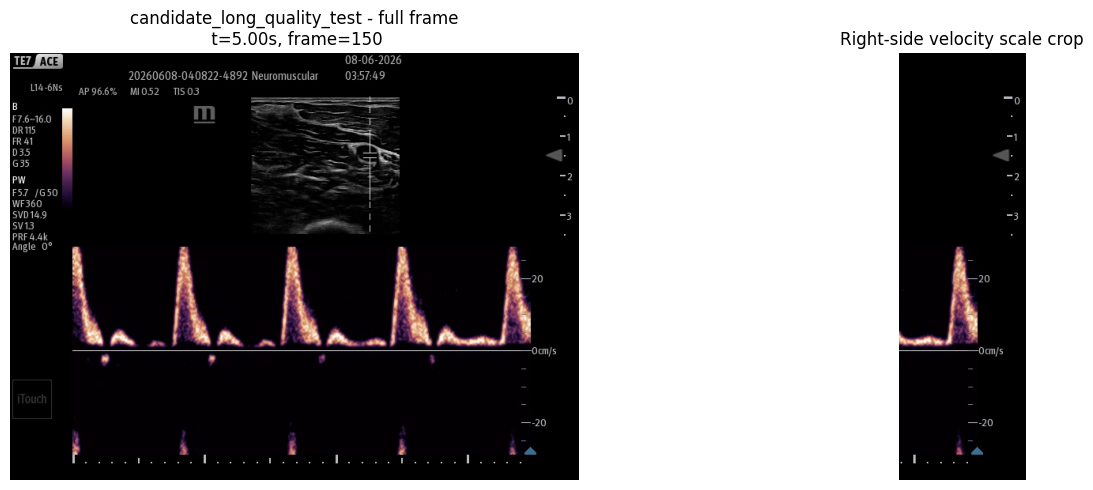

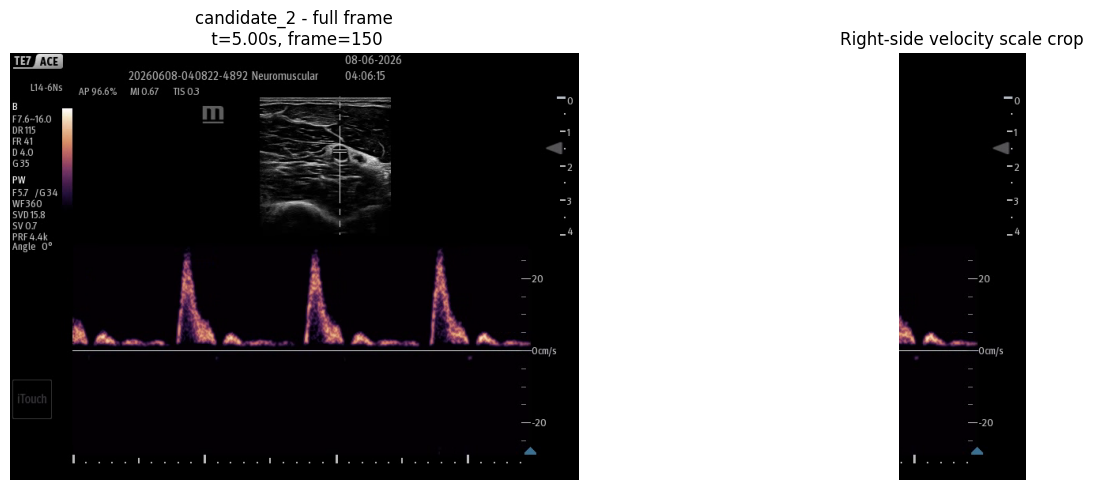

,recording_name,video_path,frame_time_s,frame_index,frame_ok,saved_frame_path,error
0,candidate_long_quality_test,D:\code\DopplerLab\ultrasound_recordings\candi...,5.0,150,True,D:\code\DopplerLab\calibration_frames\candidat...,
1,candidate_2,D:\code\DopplerLab\ultrasound_recordings\candi...,5.0,150,True,D:\code\DopplerLab\calibration_frames\candidat...,


In [40]:
CALIBRATION_FRAME_TIMES = {
    "candidate_long_quality_test": 5.0,
    "candidate_2": 5.0,
}

calibration_frame_rows = []
included_recordings_df = recording_registry_df[recording_registry_df["include_in_nb04"] == True].copy()

for _, row in included_recordings_df.iterrows():
    recording_name = row["recording_name"]
    video_path = Path(row["video_path"])
    frame_time_s = CALIBRATION_FRAME_TIMES.get(recording_name, 5.0)
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        calibration_frame_rows.append(
            {
                "recording_name": recording_name,
                "video_path": str(video_path),
                "frame_time_s": frame_time_s,
                "frame_index": np.nan,
                "frame_ok": False,
                "saved_frame_path": None,
                "error": "Could not open video.",
            }
        )
        continue

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_index = int(round(frame_time_s * fps))
    frame_index = max(0, min(frame_index, frame_count - 1))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    ok, frame_bgr = cap.read()
    cap.release()

    if not ok or frame_bgr is None:
        calibration_frame_rows.append(
            {
                "recording_name": recording_name,
                "video_path": str(video_path),
                "frame_time_s": frame_time_s,
                "frame_index": frame_index,
                "frame_ok": False,
                "saved_frame_path": None,
                "error": "Could not read frame.",
            }
        )
        continue

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    saved_frame_path = CALIBRATION_FRAME_DIR / f"{recording_name}_calibration_frame_t{frame_time_s:.1f}s.png"
    cv2.imwrite(str(saved_frame_path), frame_bgr)

    calibration_frame_rows.append(
        {
            "recording_name": recording_name,
            "video_path": str(video_path),
            "frame_time_s": frame_time_s,
            "frame_index": frame_index,
            "frame_ok": True,
            "saved_frame_path": str(saved_frame_path),
            "error": "",
        }
    )

    # Display full frame and right-side velocity scale area.
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].imshow(frame_rgb)
    axes[0].set_title(f"{recording_name} - full frame\n t={frame_time_s:.2f}s, frame={frame_index}")
    axes[0].axis("off")

    # Right-side crop where the Doppler velocity scale is expected.
    # If needed, this crop can be adjusted after visual inspection.
    x_min = 560
    x_max = frame_rgb.shape[1]

    scale_crop = frame_rgb[:, x_min:x_max]
    axes[1].imshow(scale_crop)
    axes[1].set_title("Right-side velocity scale crop")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()


calibration_frame_df = pd.DataFrame(calibration_frame_rows)
display(calibration_frame_df)

# Manual velocity scale point selection

This step displays the right-side Doppler velocity scale with pixel coordinates.

The goal is to manually identify y-pixel positions for known velocity values:

- +20 cm/s
- 0 cm/s
- -20 cm/s

These points will be used in the next step to fit a linear mapping from image pixels to Doppler velocity in cm/s.

At this stage, calibration remains manual and transparent.

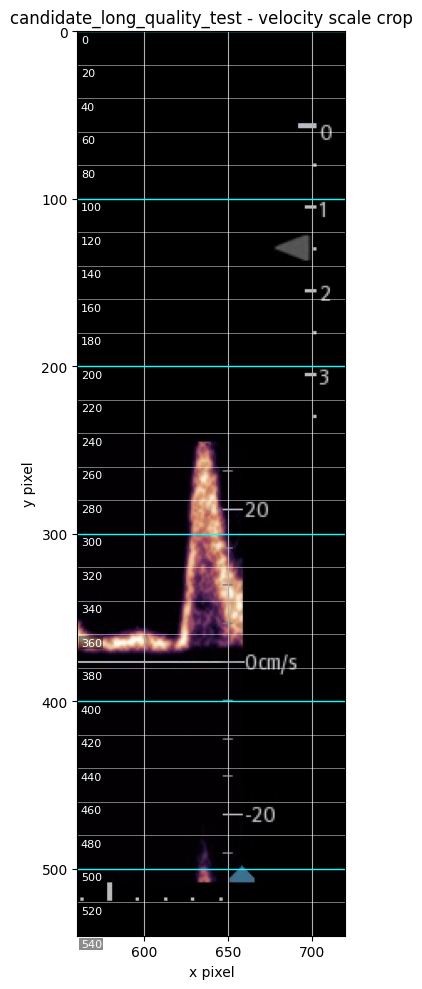

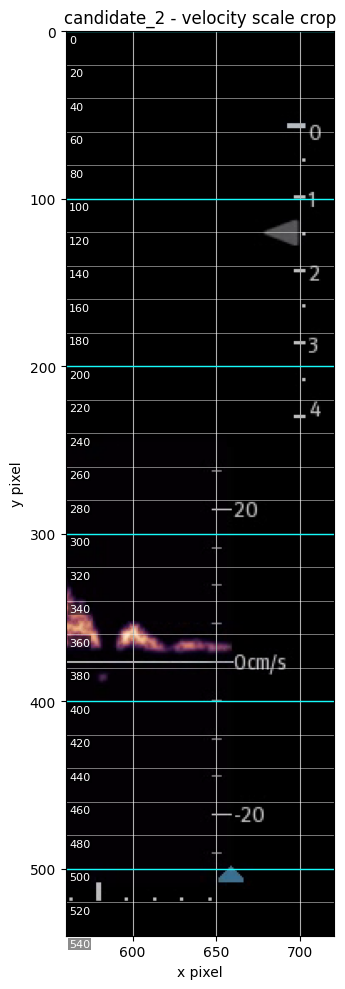

In [46]:
SCALE_CROP_X_MIN = 560
SCALE_CROP_X_MAX = 720

for _, row in calibration_frame_df.iterrows():
    recording_name = row["recording_name"]
    saved_frame_path = Path(row["saved_frame_path"])
    frame_bgr = cv2.imread(str(saved_frame_path))

    if frame_bgr is None:
        print(f"Could not read saved calibration frame: {saved_frame_path}")
        continue

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    scale_crop = frame_rgb[:, SCALE_CROP_X_MIN:SCALE_CROP_X_MAX]
    
    fig, ax = plt.subplots(figsize=(6, 10))
    ax.imshow(scale_crop, extent=[SCALE_CROP_X_MIN, SCALE_CROP_X_MAX,  frame_rgb.shape[0], 0])
    ax.set_title(f"{recording_name} - velocity scale crop", color="black")
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")

    # White helper lines every 20 pixels.
    for y in range(0, frame_rgb.shape[0] + 1, 20):
        ax.axhline(y, color="white", linewidth=0.6, alpha=0.55)
        ax.text(SCALE_CROP_X_MIN + 2, y + 2, str(y), color="white", fontsize=8, va="top", 
                bbox={"facecolor": "black", "alpha": 0.45, "edgecolor": "none", "pad": 1})

    # Stronger reference lines every 100 pixels.
    for y in range(0, frame_rgb.shape[0] + 1, 100):
        ax.axhline(y, color="cyan", linewidth=1.0, alpha=0.9)

    ax.set_xlim(SCALE_CROP_X_MIN, SCALE_CROP_X_MAX)
    ax.set_ylim(frame_rgb.shape[0], 0)

    plt.tight_layout()
    plt.show()

# Fit pixel-to-velocity calibration

This step fits a linear mapping from vertical image pixel position to Doppler velocity in cm/s.

The calibration uses manually selected points from the visible Doppler scale:

- +20 cm/s
- 0 cm/s
- -20 cm/s

Because image y-coordinates increase downward, the fitted slope is expected to be negative.

The fitted mapping will later be used to convert pixel-based Doppler morphology features into calibrated velocity features.

In [69]:
manual_velocity_calibration_points = {
    "candidate_long_quality_test": [
        {"velocity_cm_s": 20.0, "y_global": 284.5},
        {"velocity_cm_s": 0.0, "y_global": 376.0},
        {"velocity_cm_s": -20.0, "y_global": 466.5},
    ],
    "candidate_2": [
        {"velocity_cm_s": 20.0, "y_global": 284.5},
        {"velocity_cm_s": 0.0, "y_global": 376.0},
        {"velocity_cm_s": -20.0, "y_global": 466.5},
    ],
}


calibration_rows = []
calibration_point_rows = []

for recording_name, points in manual_velocity_calibration_points.items():
    point_df = pd.DataFrame(points).copy()
    point_df["recording_name"] = recording_name

    y = point_df["y_global"].to_numpy(dtype=float)
    v = point_df["velocity_cm_s"].to_numpy(dtype=float)

    fit = np.polyfit(y, v, deg=1)

    slope_cm_s_per_px = float(fit[0])
    intercept_cm_s = float(fit[1])

    predicted_v = slope_cm_s_per_px * y + intercept_cm_s
    residuals = v - predicted_v

    ss_res = float(np.sum(residuals ** 2))
    ss_tot = float(np.sum((v - np.mean(v)) ** 2))

    if ss_tot > 0:
        r2 = 1.0 - ss_res / ss_tot
    else:
        r2 = np.nan

    max_abs_error_cm_s = float(np.max(np.abs(residuals)))
    baseline_row = point_df[point_df["velocity_cm_s"] == 0.0]

    if len(baseline_row) == 1:
        baseline_y_global = float(baseline_row["y_global"].iloc[0])
    else:
        baseline_y_global = np.nan

    calibration_status = "PASS"

    if slope_cm_s_per_px >= 0:
        calibration_status = "FAIL_positive_slope"
    if max_abs_error_cm_s > 2.0:
        calibration_status = "WARN_high_fit_error"

    calibration_rows.append(
        {
            "recording_name": recording_name,
            "calibration_method": "manual_three_point_linear_fit",
            "n_calibration_points": len(point_df),
            "slope_cm_s_per_px": slope_cm_s_per_px,
            "intercept_cm_s": intercept_cm_s,
            "baseline_y_global": baseline_y_global,
            "positive_flow_side": "above_baseline",
            "r2": r2,
            "max_abs_error_cm_s": max_abs_error_cm_s,
            "calibration_status": calibration_status,
        }
    )

    point_df["predicted_velocity_cm_s"] = predicted_v
    point_df["residual_cm_s"] = residuals
    calibration_point_rows.append(point_df)


velocity_calibration_df = pd.DataFrame(calibration_rows)
velocity_calibration_points_df = pd.concat(calibration_point_rows, ignore_index=True,)
display(velocity_calibration_df)
display(velocity_calibration_points_df)

,recording_name,calibration_method,n_calibration_points,slope_cm_s_per_px,intercept_cm_s,baseline_y_global,positive_flow_side,r2,max_abs_error_cm_s,calibration_status
0,candidate_long_quality_test,manual_three_point_linear_fit,3,-0.219778,82.563272,376.0,above_baseline,0.99999,0.073259,PASS
1,candidate_2,manual_three_point_linear_fit,3,-0.219778,82.563272,376.0,above_baseline,0.99999,0.073259,PASS


,velocity_cm_s,y_global,recording_name,predicted_velocity_cm_s,residual_cm_s
0,20.0,284.5,candidate_long_quality_test,20.036428,-0.036428
1,0.0,376.0,candidate_long_quality_test,-0.073259,0.073259
2,-20.0,466.5,candidate_long_quality_test,-19.963169,-0.036831
3,20.0,284.5,candidate_2,20.036428,-0.036428
4,0.0,376.0,candidate_2,-0.073259,0.073259
5,-20.0,466.5,candidate_2,-19.963169,-0.036831


# Velocity calibration QC overlay

This step overlays the fitted velocity calibration lines on the representative Doppler frames.

The goal is to visually confirm that the fitted +20 cm/s, 0 cm/s, and -20 cm/s lines align with the visible Doppler velocity scale.

If the overlay is correct, the calibration can be used later to convert image morphology features from pixels to cm/s.

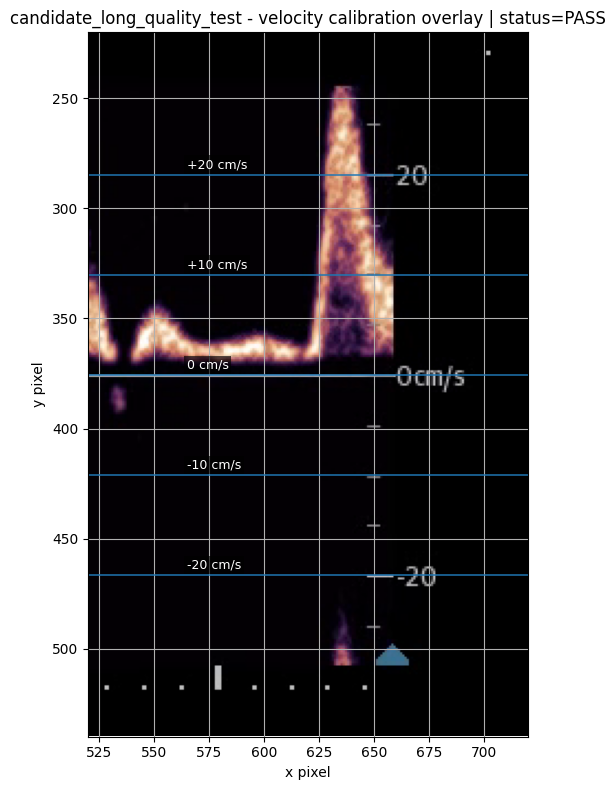

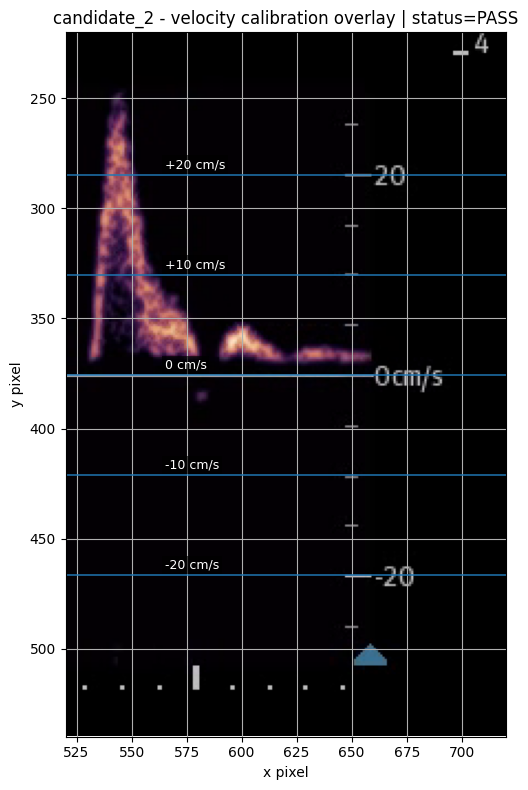

In [70]:
QC_OVERLAY_VELOCITY_LEVELS = [20, 10, 0, -10, -20]

for _, row in calibration_frame_df.iterrows():
    recording_name = row["recording_name"]
    saved_frame_path = Path(row["saved_frame_path"])
    calibration_row = velocity_calibration_df[velocity_calibration_df["recording_name"] == recording_name]

    if len(calibration_row) == 0:
        print(f"No calibration found for {recording_name}")
        continue

    calibration_row = calibration_row.iloc[0]
    slope = float(calibration_row["slope_cm_s_per_px"])
    intercept = float(calibration_row["intercept_cm_s"])
    status = calibration_row["calibration_status"]
    frame_bgr = cv2.imread(str(saved_frame_path))

    if frame_bgr is None:
        print(f"Could not read saved calibration frame: {saved_frame_path}")
        continue

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(frame_rgb)

    for velocity_cm_s in QC_OVERLAY_VELOCITY_LEVELS:
        y = (velocity_cm_s - intercept) / slope
        if velocity_cm_s > 0:
            line_label = f"+{velocity_cm_s} cm/s"
        else:
            line_label = f"{velocity_cm_s} cm/s"

        ax.axhline(y, linewidth=1.2, alpha=0.9)

        ax.text(565, y - 3, line_label, fontsize=9, color="white", 
                bbox={"facecolor": "black", "alpha": 0.65, "edgecolor": "none", "pad": 2})

    ax.set_title(f"{recording_name} - velocity calibration overlay | status={status}")
    ax.set_xlim(520, frame_rgb.shape[1])
    ax.set_ylim(frame_rgb.shape[0], 220)
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")
    plt.tight_layout()
    plt.show()

# Audio anchor beat table

This step rebuilds Doppler audio processing for QC-passed recordings.

The audio beat table is used as the timing backbone for NB04.

Audio provides:

- beat time
- RR interval
- heart-rate estimate
- audio validity flags
- usable audio segment information

Image morphology will be matched to these audio-anchored beats in later steps.

In [72]:
audio_processing_results = {}
audio_beat_tables = []
audio_summary_tables = []

included_recordings_df = recording_registry_df[recording_registry_df["include_in_nb04"] == True].copy()

for _, row in included_recordings_df.iterrows():
    recording_name = row["recording_name"]
    audio_path = Path(row["audio_path"])

    print("=" * 80)
    print(f"Processing audio: {recording_name}")
    print(f"Audio path: {audio_path}")

    audio_qc_result, audio_beat_df, audio_summary_df = process_audio_recording_with_qc(audio_path=audio_path,)

    audio_beat_df = audio_beat_df.copy()
    audio_summary_df = audio_summary_df.copy()
    audio_beat_df.insert(0, "recording_name", recording_name)
    audio_summary_df.insert(0, "recording_name", recording_name)

    audio_processing_results[recording_name] = {
        "audio_qc_result": audio_qc_result,
        "audio_beat_df": audio_beat_df,
        "audio_summary_df": audio_summary_df,
    }
    audio_beat_tables.append(audio_beat_df)
    audio_summary_tables.append(audio_summary_df)
    
audio_beat_all_df = pd.concat(audio_beat_tables, ignore_index=True)
audio_summary_all_df = pd.concat(audio_summary_tables, ignore_index=True)



# Build preliminary audio anchor table
# For now, anchor beats are based on final-valid audio beats.
# RR/HR are most reliable when consecutive final-valid beats are available.

audio_anchor_beat_df = audio_beat_all_df[audio_beat_all_df["is_valid_final"] == True].copy()
audio_anchor_beat_df["hr_bpm"] = np.nan
valid_rr_mask = (
    audio_anchor_beat_df["rr_interval_s"].notna()
    & np.isfinite(audio_anchor_beat_df["rr_interval_s"])
    & (audio_anchor_beat_df["rr_interval_s"] > 0)
)

audio_anchor_beat_df.loc[valid_rr_mask, "hr_bpm"] = (60.0 / audio_anchor_beat_df.loc[valid_rr_mask, "rr_interval_s"])
audio_anchor_beat_df = audio_anchor_beat_df.reset_index(drop=True)

# Display summaries
print()
print("Audio summary table")
print("=" * 80)
display(audio_summary_all_df)
print()
print("Audio anchor beat table")
print("=" * 80)
display(audio_anchor_beat_df)
print()
print("Audio anchor beat counts")
print("=" * 80)

audio_anchor_count_df = (audio_anchor_beat_df.groupby("recording_name").agg(n_audio_anchor_beats=("beat_id", "count"),
                        n_with_rr=("rr_interval_s", lambda x: x.notna().sum()), mean_hr_bpm=("hr_bpm", "mean"), std_hr_bpm=("hr_bpm", "std"), 
                                            first_beat_time_s=("beat_time_s", "min"), last_beat_time_s=("beat_time_s", "max"),).reset_index())

display(audio_anchor_count_df)

Processing audio: candidate_long_quality_test
Audio path: D:\code\DopplerLab\audio_exports\candidate_long_quality_test_audio.wav
D:\code\DopplerLab\audio_exports\candidate_long_quality_test_audio.wav
Sample rate : 96,000 Hz
Duration : 76.448 s
Samples : 7,339,008

Min value : -0.6598
Max value : 0.7310
Mean : -0.000006
Std : 0.024095
Detected beats: 98
Mean RR: 0.776 s
Estimated HR: 77.3 bpm
Processing audio: candidate_2
Audio path: D:\code\DopplerLab\audio_exports\candidate_2_audio.wav
D:\code\DopplerLab\audio_exports\candidate_2_audio.wav
Sample rate : 96,000 Hz
Duration : 34.219 s
Samples : 3,284,992

Min value : -0.0391
Max value : 0.0402
Mean : 0.000000
Std : 0.007193
Detected beats: 38
Mean RR: 0.905 s
Estimated HR: 66.3 bpm

Audio summary table


,recording_name,n_detected_beats,n_centroid_valid_beats,n_final_valid_beats,n_consecutive_final_rr,centroid_valid_fraction,final_valid_fraction,mean_rr_s,std_rr_s,mean_hr_bpm,mean_centroid_hz,max_centroid_hz,min_centroid_hz,recording_duration_s,usable_start_s,usable_end_s,segment_usable_duration_s,segment_usable_fraction,energy_threshold,qc_centroid_fraction
0,candidate_long_quality_test,98,94,28,25,0.959184,0.285714,0.835840,0.021783,71.784074,1619.680325,1936.043667,826.585274,76.448000,0.592000,27.269333,26.677333,0.349009,0.2,0.8
1,candidate_2,38,33,32,28,0.868421,0.842105,0.902095,0.041033,66.511824,1353.180021,1621.071526,1089.182408,34.218667,0.405333,34.208000,33.802667,0.988151,0.2,0.8



Audio anchor beat table


,recording_name,beat_id,beat_time_s,peak_centroid_hz,rr_interval_s,median_centroid_hz,qc_threshold_hz,is_valid_centroid,is_inside_usable_segment,is_valid_final,is_consecutive_final_valid,hr_bpm
0,candidate_long_quality_test,1,0.672000,1927.057538,NaN,1010.004424,808.003539,True,True,True,False,NaN
1,candidate_long_quality_test,2,1.536000,1936.043667,0.864000,1010.004424,808.003539,True,True,True,True,69.444444
2,candidate_long_quality_test,3,2.357333,1851.810508,0.821333,1010.004424,808.003539,True,True,True,True,73.051948
3,candidate_long_quality_test,4,3.178667,1851.614006,0.821333,1010.004424,808.003539,True,True,True,True,73.051948
4,candidate_long_quality_test,5,4.010667,1865.874139,0.832000,1010.004424,808.003539,True,True,True,True,72.115385
5,candidate_long_quality_test,6,4.848000,1748.663011,0.837333,1010.004424,808.003539,True,True,True,True,71.656051
6,candidate_long_quality_test,7,5.669333,1740.685910,0.821333,1010.004424,808.003539,True,True,True,True,73.051948
7,candidate_long_quality_test,8,6.501333,1780.668054,0.832000,1010.004424,808.003539,True,True,True,True,72.115385
8,candidate_long_quality_test,9,7.386667,1795.131157,0.885333,1010.004424,808.003539,True,True,True,True,67.771084
9,candidate_long_quality_test,10,8.256000,1748.321726,0.869333,1010.004424,808.003539,True,True,True,True,69.018405



Audio anchor beat counts


,recording_name,n_audio_anchor_beats,n_with_rr,mean_hr_bpm,std_hr_bpm,first_beat_time_s,last_beat_time_s
0,candidate_2,32,32,66.347979,3.156463,1.402667,33.888
1,candidate_long_quality_test,28,27,71.785659,1.823428,0.672000,26.720


# Analysis segment selection

This step defines the time window used for NB04 feature extraction.

For now, the analysis segment is based on the usable audio segment produced by the copied NB02 audio QC pipeline.

This is especially important for `candidate_long_quality_test`, where the recording contains a good initial Doppler segment followed by signal loss and non-physiological artifacts.

Only beats inside the selected analysis segment should be used for downstream image morphology matching and feature extraction.

In [74]:
analysis_segment_rows = []

for _, summary_row in audio_summary_all_df.iterrows():
    recording_name = summary_row["recording_name"]
    start_s = float(summary_row["usable_start_s"])
    end_s = float(summary_row["usable_end_s"])
    duration_s = float(summary_row["segment_usable_duration_s"])
    recording_audio_beats = audio_anchor_beat_df[audio_anchor_beat_df["recording_name"] == recording_name].copy()
    inside_segment_mask = ((recording_audio_beats["beat_time_s"] >= start_s) & (recording_audio_beats["beat_time_s"] <= end_s))
    segment_beats = recording_audio_beats[inside_segment_mask].copy()

    analysis_segment_rows.append(
        {
            "recording_name": recording_name,
            "analysis_start_s": start_s,
            "analysis_end_s": end_s,
            "analysis_duration_s": duration_s,
            "segment_usable_fraction": float(summary_row["segment_usable_fraction"]),
            "n_audio_anchor_beats_total": len(recording_audio_beats),
            "n_audio_anchor_beats_inside_segment": len(segment_beats),
            "mean_hr_bpm_inside_segment": segment_beats["hr_bpm"].mean(),
            "std_hr_bpm_inside_segment": segment_beats["hr_bpm"].std(),
            "selection_rule": "audio_usable_segment_from_nb02_qc",
        }
    )

analysis_segment_df = pd.DataFrame(analysis_segment_rows)
display(analysis_segment_df)

# Apply analysis segment flag to audio anchor beat table
audio_anchor_beat_df = audio_anchor_beat_df.copy()
audio_anchor_beat_df["inside_analysis_segment"] = False
for _, segment_row in analysis_segment_df.iterrows():
    recording_name = segment_row["recording_name"]
    start_s = segment_row["analysis_start_s"]
    end_s = segment_row["analysis_end_s"]

    mask = (
        (audio_anchor_beat_df["recording_name"] == recording_name)
        & (audio_anchor_beat_df["beat_time_s"] >= start_s) & (audio_anchor_beat_df["beat_time_s"] <= end_s))

    audio_anchor_beat_df.loc[mask, "inside_analysis_segment"] = True

audio_anchor_beat_df_inside_segment = audio_anchor_beat_df[audio_anchor_beat_df["inside_analysis_segment"] == True].copy()
print("Audio anchor beats inside NB04 analysis segments")
print("=" * 80)
display(
    audio_anchor_beat_df_inside_segment[["recording_name", "beat_id", "beat_time_s", "rr_interval_s", "hr_bpm",
                                         "is_valid_final", "is_consecutive_final_valid", "inside_analysis_segment"]])

print("Counts inside analysis segment")
print("=" * 80)

display(
    audio_anchor_beat_df_inside_segment
    .groupby("recording_name")
    .agg(
        n_beats=("beat_id", "count"),
        n_consecutive_valid=("is_consecutive_final_valid", "sum"),
        first_beat_time_s=("beat_time_s", "min"),
        last_beat_time_s=("beat_time_s", "max"),
        mean_hr_bpm=("hr_bpm", "mean"),
        std_hr_bpm=("hr_bpm", "std"),
    )
    .reset_index()
)

,recording_name,analysis_start_s,analysis_end_s,analysis_duration_s,segment_usable_fraction,n_audio_anchor_beats_total,n_audio_anchor_beats_inside_segment,mean_hr_bpm_inside_segment,std_hr_bpm_inside_segment,selection_rule
0,candidate_long_quality_test,0.592000,27.269333,26.677333,0.349009,28,28,71.785659,1.823428,audio_usable_segment_from_nb02_qc
1,candidate_2,0.405333,34.208000,33.802667,0.988151,32,32,66.347979,3.156463,audio_usable_segment_from_nb02_qc


Audio anchor beats inside NB04 analysis segments


,recording_name,beat_id,beat_time_s,rr_interval_s,hr_bpm,is_valid_final,is_consecutive_final_valid,inside_analysis_segment
0,candidate_long_quality_test,1,0.672000,NaN,NaN,True,False,True
1,candidate_long_quality_test,2,1.536000,0.864000,69.444444,True,True,True
2,candidate_long_quality_test,3,2.357333,0.821333,73.051948,True,True,True
3,candidate_long_quality_test,4,3.178667,0.821333,73.051948,True,True,True
4,candidate_long_quality_test,5,4.010667,0.832000,72.115385,True,True,True
5,candidate_long_quality_test,6,4.848000,0.837333,71.656051,True,True,True
6,candidate_long_quality_test,7,5.669333,0.821333,73.051948,True,True,True
7,candidate_long_quality_test,8,6.501333,0.832000,72.115385,True,True,True
8,candidate_long_quality_test,9,7.386667,0.885333,67.771084,True,True,True
9,candidate_long_quality_test,10,8.256000,0.869333,69.018405,True,True,True


Counts inside analysis segment


,recording_name,n_beats,n_consecutive_valid,first_beat_time_s,last_beat_time_s,mean_hr_bpm,std_hr_bpm
0,candidate_2,32,28,1.402667,33.888,66.347979,3.156463
1,candidate_long_quality_test,28,25,0.672000,26.720,71.785659,1.823428


# Video frames around audio anchor beats

This step extracts one Doppler video frame near each audio-anchored beat.

The goal is not to extract morphology yet.

The goal is to create a clean mapping between:

- audio beat time
- video frame index
- saved frame image

These frames will later be used to extract image morphology candidates and match them back to audio beats.

In [76]:
BEAT_FRAME_EXPORT_DIR = PROJECT_ROOT / "beat_frames"
BEAT_FRAME_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

beat_frame_rows = []
for recording_name, beat_df in audio_anchor_beat_df_inside_segment.groupby("recording_name"):
    registry_row = recording_registry_df[recording_registry_df["recording_name"] == recording_name].iloc[0]
    video_path = Path(registry_row["video_path"])
    cap = cv2.VideoCapture(str(video_path))
    
    if not cap.isOpened():
        print(f"Could not open video for {recording_name}: {video_path}")
        continue

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    recording_frame_dir = BEAT_FRAME_EXPORT_DIR / recording_name
    recording_frame_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 80)
    print(f"Extracting beat frames: {recording_name}")
    print(f"Video path: {video_path}")
    print(f"FPS: {fps:.3f}")
    print(f"Frame count: {frame_count}")

    for _, beat_row in beat_df.iterrows():
        beat_id = int(beat_row["beat_id"])
        beat_time_s = float(beat_row["beat_time_s"])
        frame_index = int(round(beat_time_s * fps))
        frame_index = max(0, min(frame_index, frame_count - 1))
        frame_time_s = frame_index / fps
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
        ok, frame_bgr = cap.read()
        saved_frame_path = None
        error = ""

        if ok and frame_bgr is not None:
            saved_frame_path = (recording_frame_dir / f"{recording_name}_beat_{beat_id:04d}_t{beat_time_s:.3f}s_frame_{frame_index:06d}.png")
            cv2.imwrite(str(saved_frame_path), frame_bgr)
        else:
            error = "Could not read frame."
        beat_frame_rows.append(
            {
                "recording_name": recording_name,
                "beat_id": beat_id,
                "beat_time_s": beat_time_s,
                "frame_time_s": frame_time_s,
                "frame_index": frame_index,
                "frame_ok": bool(ok and frame_bgr is not None),
                "saved_frame_path": str(saved_frame_path) if saved_frame_path is not None else None,
                "frame_time_error_s": frame_time_s - beat_time_s,
                "error": error,
            }
        )

    cap.release()


beat_frame_df = pd.DataFrame(beat_frame_rows)
display(beat_frame_df)

print("Beat frame extraction summary")
print("=" * 80)

display(
    beat_frame_df
    .groupby("recording_name")
    .agg(
        n_rows=("beat_id", "count"),
        n_ok=("frame_ok", "sum"),
        mean_abs_frame_time_error_s=("frame_time_error_s", lambda x: np.mean(np.abs(x))),
        max_abs_frame_time_error_s=("frame_time_error_s", lambda x: np.max(np.abs(x))),
        first_frame_index=("frame_index", "min"),
        last_frame_index=("frame_index", "max"),
    )
    .reset_index()
)

Extracting beat frames: candidate_2
Video path: D:\code\DopplerLab\ultrasound_recordings\candidate_2.avi
FPS: 30.000
Frame count: 1028
Extracting beat frames: candidate_long_quality_test
Video path: D:\code\DopplerLab\ultrasound_recordings\candidate_long_quality_test.avi
FPS: 30.000
Frame count: 2295


,recording_name,beat_id,beat_time_s,frame_time_s,frame_index,frame_ok,saved_frame_path,frame_time_error_s,error
0,candidate_2,2,1.402667,1.400000,42,True,D:\code\DopplerLab\beat_frames\candidate_2\can...,-0.002667,
1,candidate_2,3,2.373333,2.366667,71,True,D:\code\DopplerLab\beat_frames\candidate_2\can...,-0.006667,
2,candidate_2,4,3.349333,3.333333,100,True,D:\code\DopplerLab\beat_frames\candidate_2\can...,-0.016000,
3,candidate_2,5,4.298667,4.300000,129,True,D:\code\DopplerLab\beat_frames\candidate_2\can...,0.001333,
4,candidate_2,6,5.237333,5.233333,157,True,D:\code\DopplerLab\beat_frames\candidate_2\can...,-0.004000,
5,candidate_2,7,6.176000,6.166667,185,True,D:\code\DopplerLab\beat_frames\candidate_2\can...,-0.009333,
6,candidate_2,8,7.125333,7.133333,214,True,D:\code\DopplerLab\beat_frames\candidate_2\can...,0.008000,
7,candidate_2,9,8.085333,8.100000,243,True,D:\code\DopplerLab\beat_frames\candidate_2\can...,0.014667,
8,candidate_2,10,9.034667,9.033333,271,True,D:\code\DopplerLab\beat_frames\candidate_2\can...,-0.001333,
9,candidate_2,11,9.973333,9.966667,299,True,D:\code\DopplerLab\beat_frames\candidate_2\can...,-0.006667,


Beat frame extraction summary


,recording_name,n_rows,n_ok,mean_abs_frame_time_error_s,max_abs_frame_time_error_s,first_frame_index,last_frame_index
0,candidate_2,32,32,0.008708,0.016,42,1017
1,candidate_long_quality_test,28,28,0.008381,0.016,20,802


# Image morphology extraction smoke test

This step tests whether the copied NB01 image extraction functions work correctly on saved beat frames.

Only a small sample of frames is tested first.

The goal is to verify:

- Doppler envelope extraction
- baseline detection
- peak detection
- beat morphology table generation

Full image morphology extraction for all beat frames will be performed only after this smoke test passes.

Testing image morphology extraction
Recording: candidate_2
Beat ID: 2
Time: 1.403 s
Frame: D:\code\DopplerLab\beat_frames\candidate_2\candidate_2_beat_0002_t1.403s_frame_000042.png
Extraction OK | peaks=3 | beat rows=2


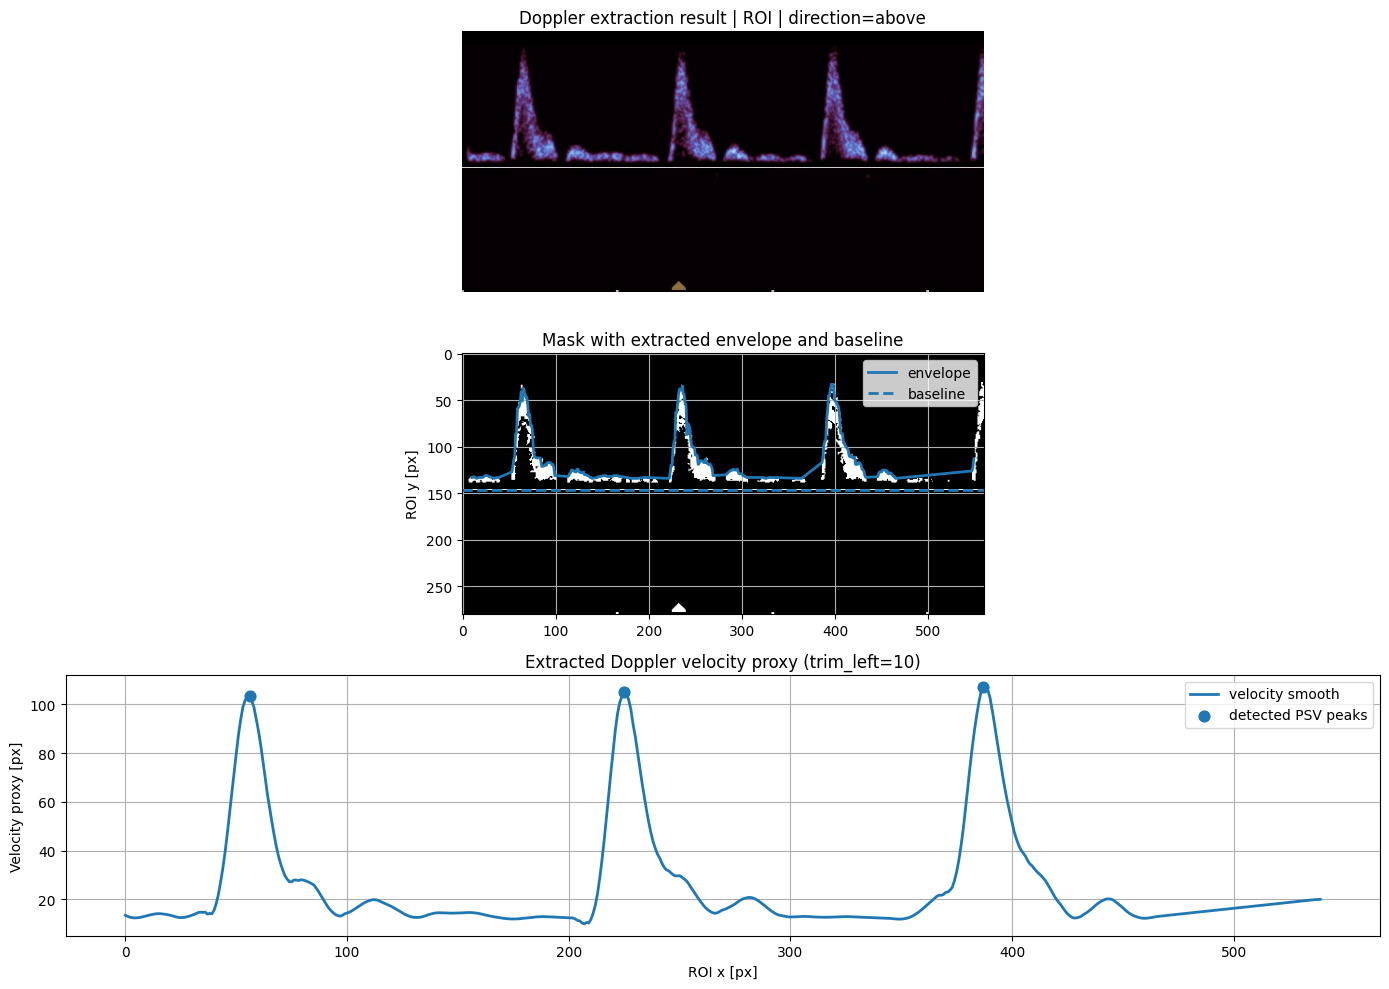

,beat_id,is_complete_beat,beat_quality_reason,psv_local,psv_global,psv_value_px,next_psv_local,next_psv_global,first_valley_local,first_valley_global,first_valley_value_px,secondary_peak_local,secondary_peak_global,secondary_peak_value_px,cycle_length_px,time_to_valley_px,time_to_secondary_peak_px,valley_to_psv_ratio,secondary_to_psv_ratio,ri_proxy
0,1,False,valley_too_late;missing_secondary_peak,56,66,103.304675,225,235,207,217,9.989369,NaN,NaN,NaN,169,151,NaN,0.096698,NaN,0.903302
1,2,False,valley_too_late;missing_secondary_peak,225,235,104.970252,387,397,349,359,11.930218,NaN,NaN,NaN,162,124,NaN,0.113653,NaN,0.886347


Testing image morphology extraction
Recording: candidate_2
Beat ID: 18
Time: 16.203 s
Frame: D:\code\DopplerLab\beat_frames\candidate_2\candidate_2_beat_0018_t16.203s_frame_000486.png
Extraction OK | peaks=3 | beat rows=2


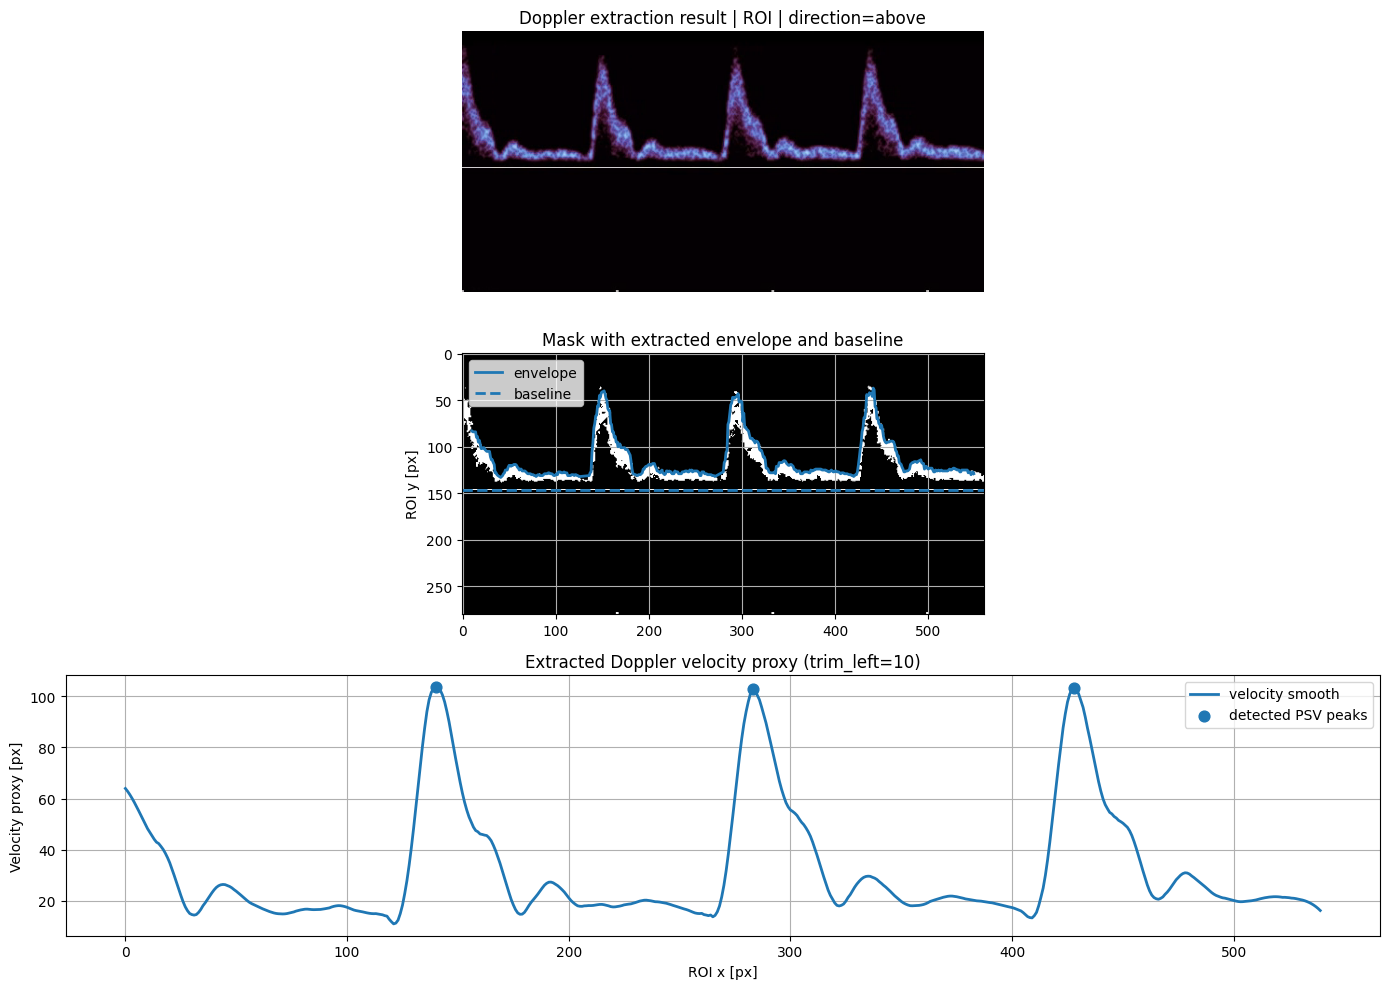

,beat_id,is_complete_beat,beat_quality_reason,psv_local,psv_global,psv_value_px,next_psv_local,next_psv_global,first_valley_local,first_valley_global,first_valley_value_px,secondary_peak_local,secondary_peak_global,secondary_peak_value_px,cycle_length_px,time_to_valley_px,time_to_secondary_peak_px,valley_to_psv_ratio,secondary_to_psv_ratio,ri_proxy
0,1,False,valley_too_late;missing_secondary_peak,140,150,103.617522,283,293,265,275,13.824307,NaN,NaN,NaN,143,125,NaN,0.133417,NaN,0.866583
1,2,False,valley_too_late;missing_secondary_peak,283,293,102.616868,428,438,409,419,13.400131,NaN,NaN,NaN,145,126,NaN,0.130584,NaN,0.869416


Testing image morphology extraction
Recording: candidate_2
Beat ID: 38
Time: 33.888 s
Frame: D:\code\DopplerLab\beat_frames\candidate_2\candidate_2_beat_0038_t33.888s_frame_001017.png
Extraction OK | peaks=3 | beat rows=2


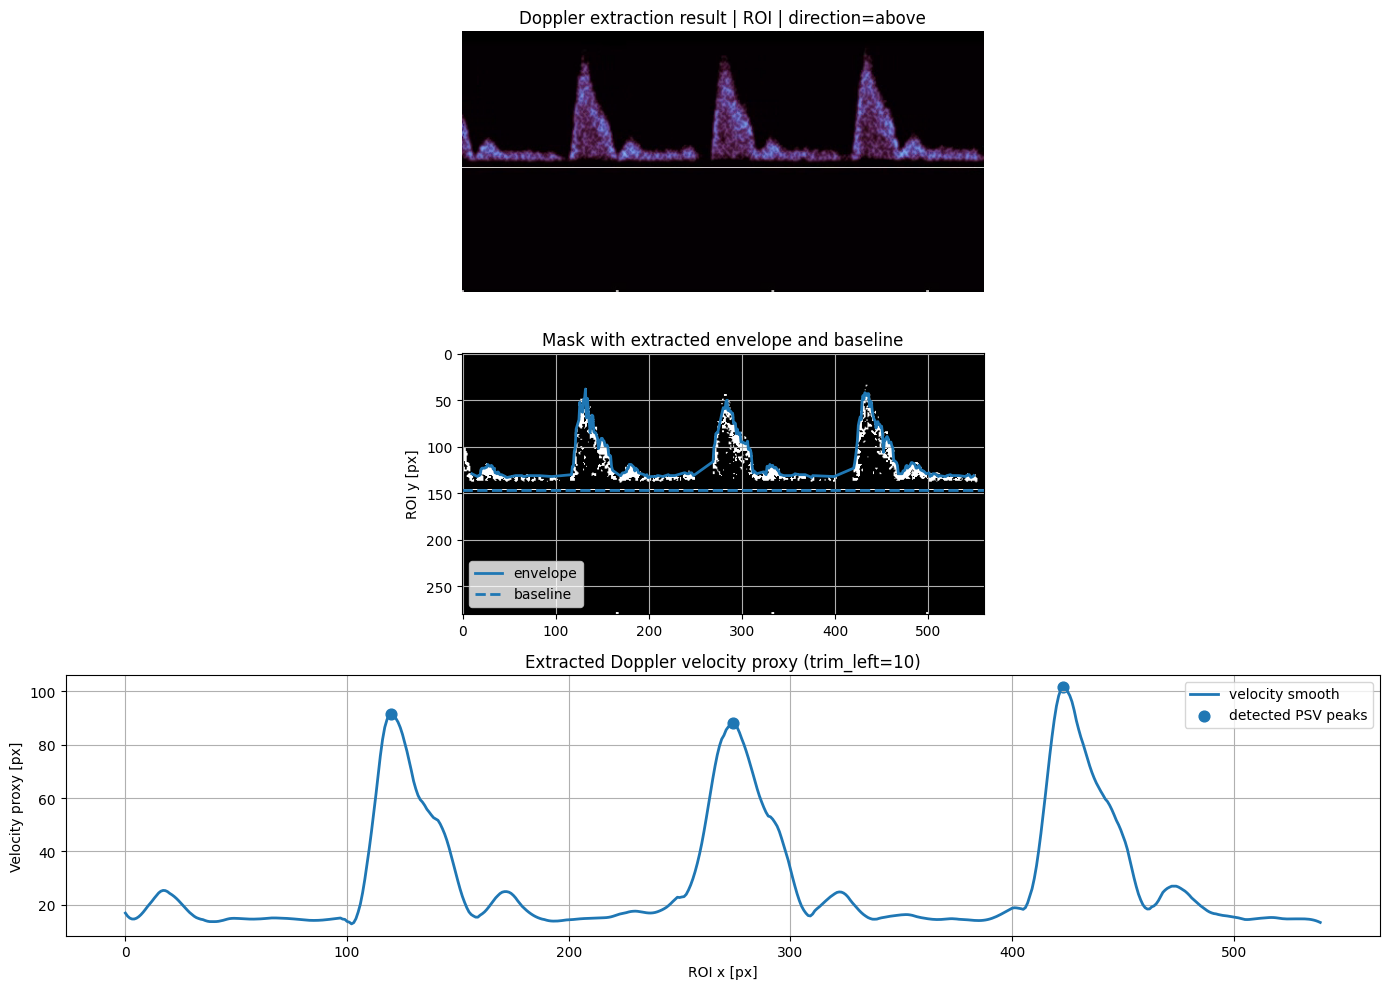

,beat_id,is_complete_beat,beat_quality_reason,psv_local,psv_global,psv_value_px,next_psv_local,next_psv_global,first_valley_local,first_valley_global,first_valley_value_px,secondary_peak_local,secondary_peak_global,secondary_peak_value_px,cycle_length_px,time_to_valley_px,time_to_secondary_peak_px,valley_to_psv_ratio,secondary_to_psv_ratio,ri_proxy
0,1,False,missing_secondary_peak,120,130,91.309742,274,284,193,203,13.881911,NaN,NaN,NaN,154,73,NaN,0.152031,NaN,0.847969
1,2,False,valley_too_late;missing_secondary_peak,274,284,87.998039,423,433,385,395,14.089970,NaN,NaN,NaN,149,111,NaN,0.160117,NaN,0.839883


Testing image morphology extraction
Recording: candidate_long_quality_test
Beat ID: 1
Time: 0.672 s
Frame: D:\code\DopplerLab\beat_frames\candidate_long_quality_test\candidate_long_quality_test_beat_0001_t0.672s_frame_000020.png
Extraction OK | peaks=4 | beat rows=3


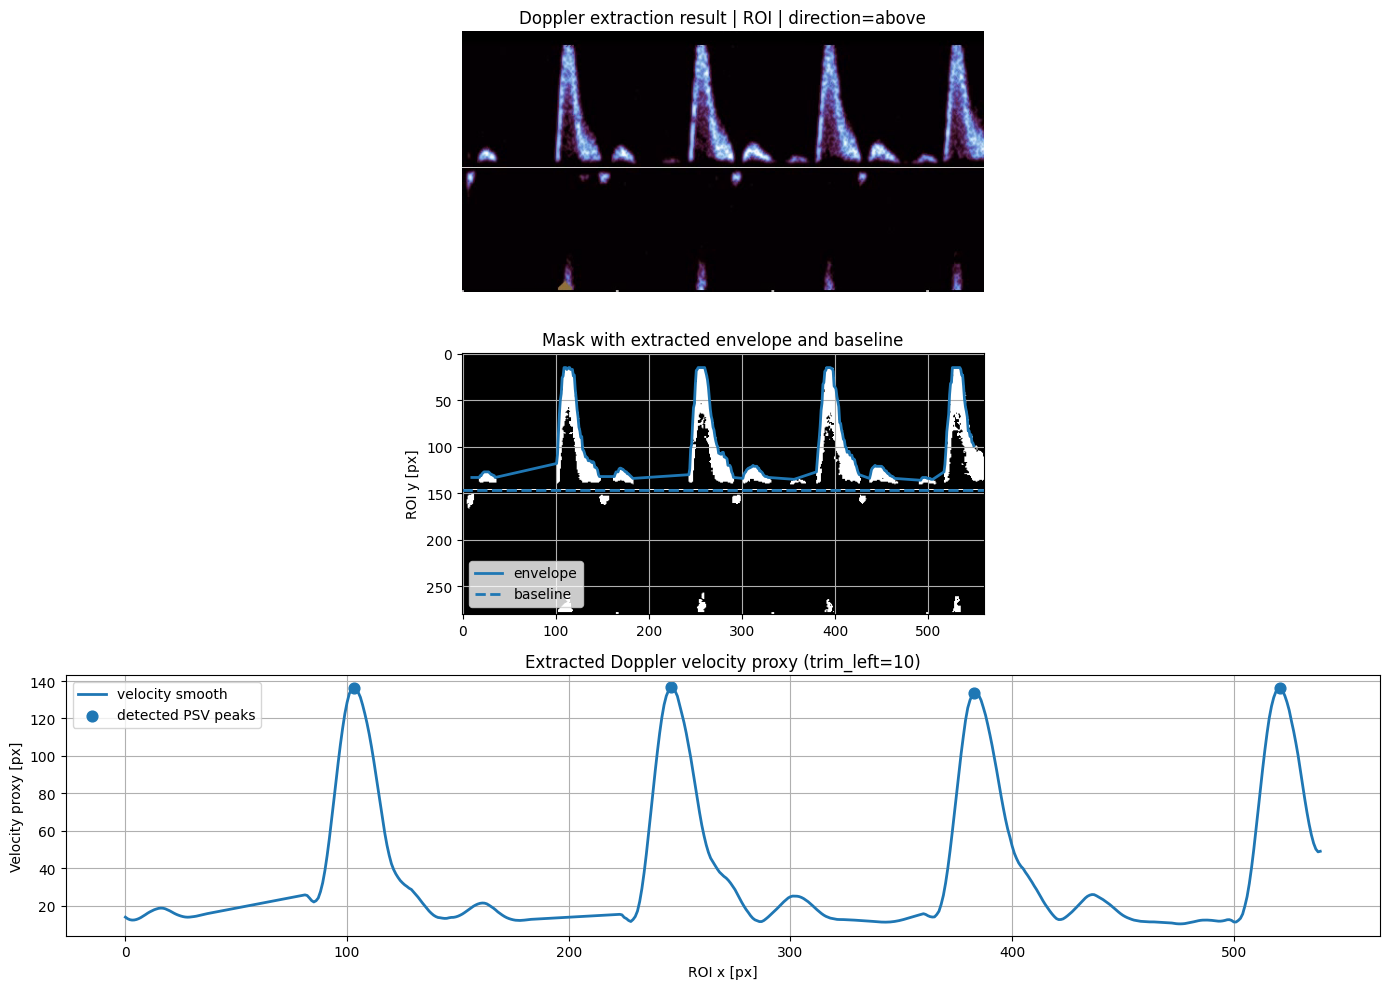

,beat_id,is_complete_beat,beat_quality_reason,psv_local,psv_global,psv_value_px,next_psv_local,next_psv_global,first_valley_local,first_valley_global,first_valley_value_px,secondary_peak_local,secondary_peak_global,secondary_peak_value_px,cycle_length_px,time_to_valley_px,time_to_secondary_peak_px,valley_to_psv_ratio,secondary_to_psv_ratio,ri_proxy
0,1,False,valley_too_late;missing_secondary_peak,103,113,136.089572,246,256,228,238,11.500708,NaN,NaN,NaN,143,125,NaN,0.084508,NaN,0.915492
1,2,False,valley_too_late;missing_secondary_peak,246,256,136.922524,383,393,343,353,11.164634,NaN,NaN,NaN,137,97,NaN,0.081540,NaN,0.918460
2,3,False,valley_too_late;missing_secondary_peak,383,393,133.810069,521,531,476,486,10.242890,NaN,NaN,NaN,138,93,NaN,0.076548,NaN,0.923452


Testing image morphology extraction
Recording: candidate_long_quality_test
Beat ID: 15
Time: 12.491 s
Frame: D:\code\DopplerLab\beat_frames\candidate_long_quality_test\candidate_long_quality_test_beat_0015_t12.491s_frame_000375.png
Extraction OK | peaks=4 | beat rows=3


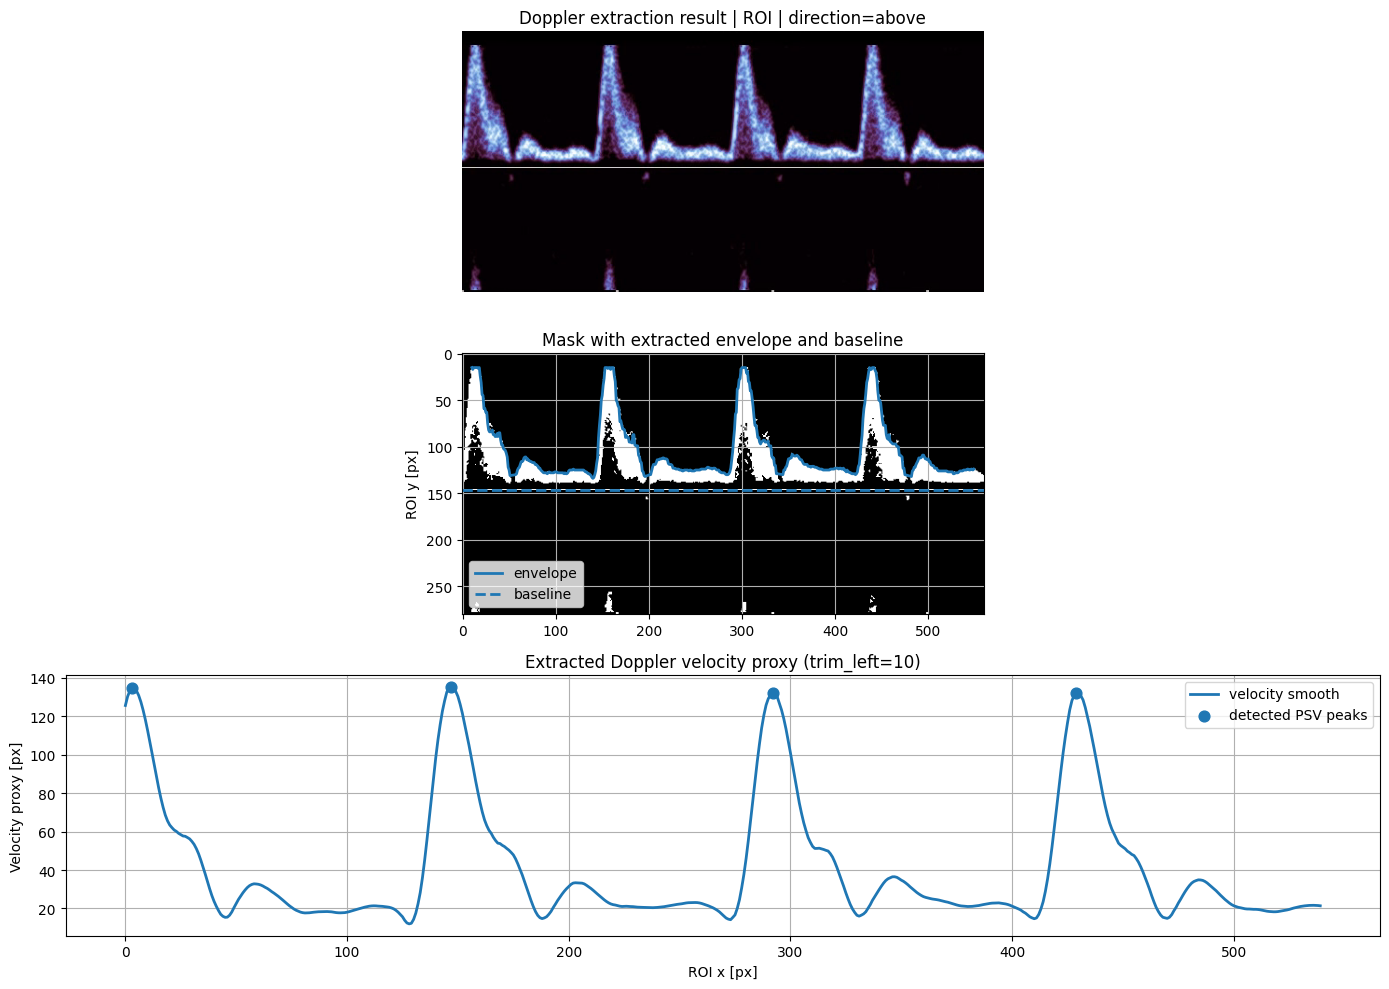

,beat_id,is_complete_beat,beat_quality_reason,psv_local,psv_global,psv_value_px,next_psv_local,next_psv_global,first_valley_local,first_valley_global,first_valley_value_px,secondary_peak_local,secondary_peak_global,secondary_peak_value_px,cycle_length_px,time_to_valley_px,time_to_secondary_peak_px,valley_to_psv_ratio,secondary_to_psv_ratio,ri_proxy
0,1,False,valley_too_late;missing_secondary_peak,3,13,134.630360,147,157,128,138,11.985616,NaN,NaN,NaN,144,125,NaN,0.089026,NaN,0.910974
1,2,False,valley_too_late;missing_secondary_peak,147,157,135.338346,292,302,273,283,14.154299,NaN,NaN,NaN,145,126,NaN,0.104585,NaN,0.895415
2,3,False,valley_too_late;missing_secondary_peak,292,302,131.881988,429,439,410,420,14.658712,NaN,NaN,NaN,137,118,NaN,0.111150,NaN,0.888850


Testing image morphology extraction
Recording: candidate_long_quality_test
Beat ID: 32
Time: 26.720 s
Frame: D:\code\DopplerLab\beat_frames\candidate_long_quality_test\candidate_long_quality_test_beat_0032_t26.720s_frame_000802.png
Extraction OK | peaks=1 | beat rows=0


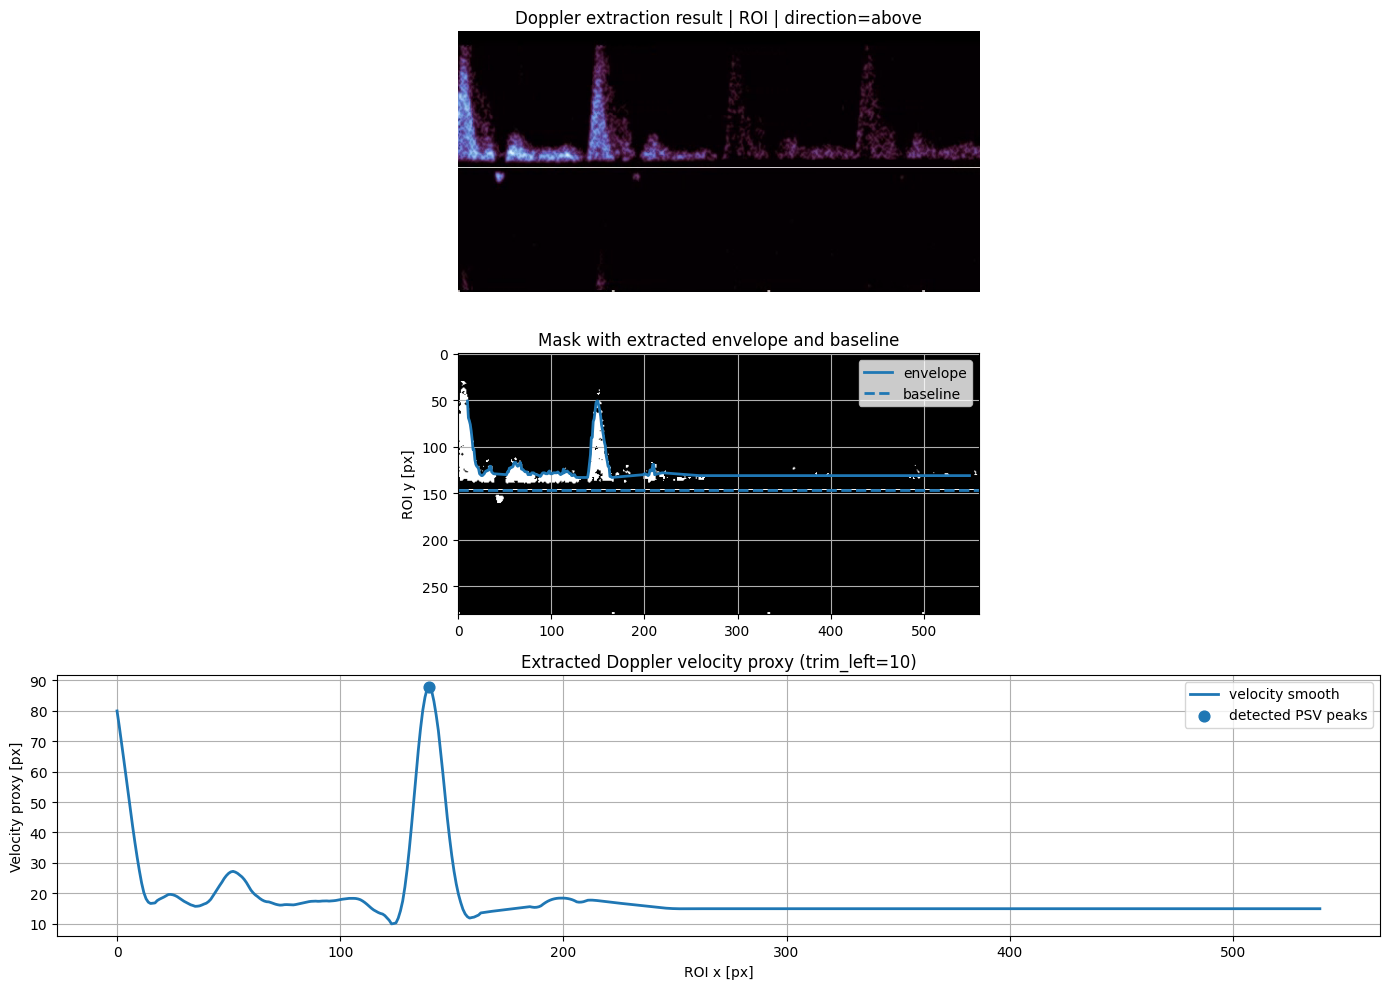

""


Image morphology smoke test summary


,recording_name,beat_id,beat_time_s,frame_path,extraction_ok,n_peaks,n_beats,baseline,direction,error
0,candidate_2,2,1.402667,D:\code\DopplerLab\beat_frames\candidate_2\can...,True,3,2,146,above,
1,candidate_2,18,16.202667,D:\code\DopplerLab\beat_frames\candidate_2\can...,True,3,2,146,above,
2,candidate_2,38,33.888000,D:\code\DopplerLab\beat_frames\candidate_2\can...,True,3,2,146,above,
3,candidate_long_quality_test,1,0.672000,D:\code\DopplerLab\beat_frames\candidate_long_...,True,4,3,146,above,
4,candidate_long_quality_test,15,12.490667,D:\code\DopplerLab\beat_frames\candidate_long_...,True,4,3,146,above,
5,candidate_long_quality_test,32,26.720000,D:\code\DopplerLab\beat_frames\candidate_long_...,True,1,0,146,above,


In [77]:
def select_frame_samples_for_morphology_test(beat_frame_df, n_per_recording=3):
    """
    Select a small sample of beat frames per recording for morphology smoke testing.

    The selected frames are approximately:
    - first frame
    - middle frame
    - last frame

    Parameters
    ----------
    beat_frame_df : pd.DataFrame
        Table with saved beat frames.

    n_per_recording : int
        Number of frames to select per recording. Currently expected to be 3.

    Returns
    -------
    pd.DataFrame
        Sampled rows from beat_frame_df.
    """

    sample_rows = []
    for recording_name, group_df in beat_frame_df.groupby("recording_name"):
        group_df = group_df.sort_values("beat_time_s").reset_index(drop=True)
        if len(group_df) == 0:
            continue
        if len(group_df) <= n_per_recording:
            selected_indices = list(range(len(group_df)))
        else:
            selected_indices = [
                0,
                len(group_df) // 2,
                len(group_df) - 1,
            ]
        sample_rows.append(group_df.iloc[selected_indices])

    if len(sample_rows) == 0:
        return pd.DataFrame()
    return pd.concat(sample_rows, ignore_index=True)

morphology_test_frame_df = select_frame_samples_for_morphology_test(
    beat_frame_df=beat_frame_df,
    n_per_recording=3,
)
morphology_test_rows = []
morphology_test_results = {}

for _, row in morphology_test_frame_df.iterrows():
    recording_name = row["recording_name"]
    beat_id = int(row["beat_id"])
    beat_time_s = float(row["beat_time_s"])
    frame_path = Path(row["saved_frame_path"])
    print("=" * 80)
    print(f"Testing image morphology extraction")
    print(f"Recording: {recording_name}")
    print(f"Beat ID: {beat_id}")
    print(f"Time: {beat_time_s:.3f} s")
    print(f"Frame: {frame_path}")

    frame_bgr = cv2.imread(str(frame_path))
    if frame_bgr is None:
        print("Could not read frame.")
        morphology_test_rows.append(
            {
                "recording_name": recording_name,
                "beat_id": beat_id,
                "beat_time_s": beat_time_s,
                "frame_path": str(frame_path),
                "extraction_ok": False,
                "n_peaks": 0,
                "n_beats": 0,
                "baseline": np.nan,
                "direction": None,
                "error": "Could not read frame.",
            }
        )
        continue

    try:
        extraction_result = extract_doppler_waveform(frame_bgr)
        beat_morphology_df = analyze_beats(extraction_result)
        n_peaks = len(extraction_result.get("peaks", []))
        n_beats = len(beat_morphology_df)
        morphology_test_results[(recording_name, beat_id)] = {
            "extraction_result": extraction_result,
            "beat_morphology_df": beat_morphology_df,
        }

        morphology_test_rows.append(
            {
                "recording_name": recording_name,
                "beat_id": beat_id,
                "beat_time_s": beat_time_s,
                "frame_path": str(frame_path),
                "extraction_ok": True,
                "n_peaks": n_peaks,
                "n_beats": n_beats,
                "baseline": extraction_result.get("baseline", np.nan),
                "direction": extraction_result.get("direction", None),
                "error": "",
            }
        )

        print(f"Extraction OK | peaks={n_peaks} | beat rows={n_beats}")
        plot_doppler_extraction_result(extraction_result)
        display(beat_morphology_df)

    except Exception as exc:
        print(f"Extraction failed: {exc}")
        morphology_test_rows.append(
            {
                "recording_name": recording_name,
                "beat_id": beat_id,
                "beat_time_s": beat_time_s,
                "frame_path": str(frame_path),
                "extraction_ok": False,
                "n_peaks": 0,
                "n_beats": 0,
                "baseline": np.nan,
                "direction": None,
                "error": str(exc),
            }
        )


morphology_test_summary_df = pd.DataFrame(morphology_test_rows)
print("Image morphology smoke test summary")
print("=" * 80)

display(morphology_test_summary_df)

# Image morphology candidate extraction

This step extracts Doppler image morphology candidates from all saved beat frames.

Each video frame may contain more than one visible Doppler beat because the ultrasound screen displays a sweep window.

Therefore, this table is not the final beat-level ground truth table.

It is only a candidate table.

Later steps will match image morphology candidates to audio anchor beats and remove duplicated candidates.

In [78]:
image_morphology_candidate_rows = []
image_morphology_extraction_rows = []
for _, frame_row in beat_frame_df.iterrows():
    recording_name = frame_row["recording_name"]
    audio_beat_id = int(frame_row["beat_id"])
    audio_beat_time_s = float(frame_row["beat_time_s"])
    frame_time_s = float(frame_row["frame_time_s"])
    frame_index = int(frame_row["frame_index"])
    frame_path = Path(frame_row["saved_frame_path"])
    frame_bgr = cv2.imread(str(frame_path))
    if frame_bgr is None:
        image_morphology_extraction_rows.append(
            {
                "recording_name": recording_name,
                "audio_beat_id": audio_beat_id,
                "audio_beat_time_s": audio_beat_time_s,
                "frame_time_s": frame_time_s,
                "frame_index": frame_index,
                "frame_path": str(frame_path),
                "extraction_ok": False,
                "n_peaks": 0,
                "n_candidate_beats": 0,
                "baseline": np.nan,
                "direction": None,
                "error": "Could not read frame.",
            }
        )
        continue

    try:
        extraction_result = extract_doppler_waveform(frame_bgr)
        beat_df = analyze_beats(extraction_result)
        n_peaks = len(extraction_result.get("peaks", []))
        n_candidate_beats = len(beat_df)
        image_morphology_extraction_rows.append(
            {
                "recording_name": recording_name,
                "audio_beat_id": audio_beat_id,
                "audio_beat_time_s": audio_beat_time_s,
                "frame_time_s": frame_time_s,
                "frame_index": frame_index,
                "frame_path": str(frame_path),
                "extraction_ok": True,
                "n_peaks": n_peaks,
                "n_candidate_beats": n_candidate_beats,
                "baseline": extraction_result.get("baseline", np.nan),
                "direction": extraction_result.get("direction", None),
                "error": "",
            }
        )

        if len(beat_df) == 0:
            continue
        for _, candidate_row in beat_df.iterrows():
            candidate = candidate_row.to_dict()
            candidate.update(
                {
                    "recording_name": recording_name,
                    "audio_beat_id": audio_beat_id,
                    "audio_beat_time_s": audio_beat_time_s,
                    "frame_time_s": frame_time_s,
                    "frame_index": frame_index,
                    "frame_path": str(frame_path),
                    "extraction_baseline": extraction_result.get("baseline", np.nan),
                    "extraction_direction": extraction_result.get("direction", None),
                    "n_frame_peaks": n_peaks,
                }
            )
            image_morphology_candidate_rows.append(candidate)
    except Exception as exc:
        image_morphology_extraction_rows.append(
            {
                "recording_name": recording_name,
                "audio_beat_id": audio_beat_id,
                "audio_beat_time_s": audio_beat_time_s,
                "frame_time_s": frame_time_s,
                "frame_index": frame_index,
                "frame_path": str(frame_path),
                "extraction_ok": False,
                "n_peaks": 0,
                "n_candidate_beats": 0,
                "baseline": np.nan,
                "direction": None,
                "error": str(exc),
            }
        )


image_morphology_extraction_df = pd.DataFrame(image_morphology_extraction_rows)
image_morphology_candidate_df = pd.DataFrame(image_morphology_candidate_rows)

# Add velocity calibration to image morphology candidates
# NB01 morphology values are pixel-distance velocity proxies.
# Since calibration slope is cm/s per y-pixel, pixel-distance values can be converted using abs(slope_cm_s_per_px).

calibration_scale_df = velocity_calibration_df[["recording_name", "slope_cm_s_per_px", "baseline_y_global", "calibration_status"]].copy()
calibration_scale_df["cm_s_per_px"] = calibration_scale_df["slope_cm_s_per_px"].abs()

if len(image_morphology_candidate_df) > 0:
    image_morphology_candidate_df = image_morphology_candidate_df.merge(calibration_scale_df, on="recording_name", how="left")
    image_morphology_candidate_df["psv_cm_s"] = (image_morphology_candidate_df["psv_value_px"] * image_morphology_candidate_df["cm_s_per_px"])
    image_morphology_candidate_df["edv_proxy_cm_s"] = (image_morphology_candidate_df["first_valley_value_px"] 
                                                       * image_morphology_candidate_df["cm_s_per_px"])
    image_morphology_candidate_df["secondary_peak_cm_s"] = (image_morphology_candidate_df["secondary_peak_value_px"] 
                                                            * image_morphology_candidate_df["cm_s_per_px"])

    image_morphology_candidate_df["ri_calibrated"] = ((image_morphology_candidate_df["psv_cm_s"] - image_morphology_candidate_df["edv_proxy_cm_s"]) 
                                                      / image_morphology_candidate_df["psv_cm_s"])

# Display extraction summary
print("Image morphology extraction summary")
print("=" * 80)
display(image_morphology_extraction_df)
print("Image morphology extraction counts")
print("=" * 80)
display(
    image_morphology_extraction_df
    .groupby("recording_name")
    .agg(
        n_frames=("frame_index", "count"),
        n_extraction_ok=("extraction_ok", "sum"),
        n_total_candidate_beats=("n_candidate_beats", "sum"),
        mean_candidate_beats_per_frame=("n_candidate_beats", "mean"),
        min_candidate_beats_per_frame=("n_candidate_beats", "min"),
        max_candidate_beats_per_frame=("n_candidate_beats", "max"),
        mean_peaks_per_frame=("n_peaks", "mean"),
    )
    .reset_index()
)

print("Image morphology candidate table")
print("=" * 80)
display(image_morphology_candidate_df)
print("Candidate quality summary")
print("=" * 80)

if len(image_morphology_candidate_df) > 0:
    display(
        image_morphology_candidate_df
        .groupby(["recording_name", "is_complete_beat"])
        .agg(
            n_candidates=("beat_id", "count"),
            mean_psv_px=("psv_value_px", "mean"),
            mean_psv_cm_s=("psv_cm_s", "mean"),
            mean_edv_proxy_cm_s=("edv_proxy_cm_s", "mean"),
            mean_ri_proxy=("ri_proxy", "mean"),
            mean_ri_calibrated=("ri_calibrated", "mean"),
        )
        .reset_index()
    )

    display(
        image_morphology_candidate_df["beat_quality_reason"]
        .value_counts(dropna=False)
        .reset_index()
        .rename(
            columns={
                "index": "beat_quality_reason",
                "beat_quality_reason": "n_candidates",
            }
        )
    )
else:
    print("No image morphology candidates were extracted.")

Image morphology extraction summary


,recording_name,audio_beat_id,audio_beat_time_s,frame_time_s,frame_index,frame_path,extraction_ok,n_peaks,n_candidate_beats,baseline,direction,error
0,candidate_2,2,1.402667,1.400000,42,D:\code\DopplerLab\beat_frames\candidate_2\can...,True,3,2,146,above,
1,candidate_2,3,2.373333,2.366667,71,D:\code\DopplerLab\beat_frames\candidate_2\can...,True,3,2,146,above,
2,candidate_2,4,3.349333,3.333333,100,D:\code\DopplerLab\beat_frames\candidate_2\can...,True,3,2,146,above,
3,candidate_2,5,4.298667,4.300000,129,D:\code\DopplerLab\beat_frames\candidate_2\can...,True,3,2,146,above,
4,candidate_2,6,5.237333,5.233333,157,D:\code\DopplerLab\beat_frames\candidate_2\can...,True,3,2,146,above,
5,candidate_2,7,6.176000,6.166667,185,D:\code\DopplerLab\beat_frames\candidate_2\can...,True,3,2,146,above,
6,candidate_2,8,7.125333,7.133333,214,D:\code\DopplerLab\beat_frames\candidate_2\can...,True,3,2,146,above,
7,candidate_2,9,8.085333,8.100000,243,D:\code\DopplerLab\beat_frames\candidate_2\can...,True,3,2,146,above,
8,candidate_2,10,9.034667,9.033333,271,D:\code\DopplerLab\beat_frames\candidate_2\can...,True,3,2,146,above,
9,candidate_2,11,9.973333,9.966667,299,D:\code\DopplerLab\beat_frames\candidate_2\can...,True,3,2,146,above,


Image morphology extraction counts


,recording_name,n_frames,n_extraction_ok,n_total_candidate_beats,mean_candidate_beats_per_frame,min_candidate_beats_per_frame,max_candidate_beats_per_frame,mean_peaks_per_frame
0,candidate_2,32,32,66,2.062500,2,3,3.062500
1,candidate_long_quality_test,28,28,78,2.785714,0,3,3.785714


Image morphology candidate table


,beat_id,is_complete_beat,beat_quality_reason,psv_local,psv_global,psv_value_px,next_psv_local,next_psv_global,first_valley_local,first_valley_global,first_valley_value_px,secondary_peak_local,secondary_peak_global,secondary_peak_value_px,cycle_length_px,time_to_valley_px,time_to_secondary_peak_px,valley_to_psv_ratio,secondary_to_psv_ratio,ri_proxy,recording_name,audio_beat_id,audio_beat_time_s,frame_time_s,frame_index,frame_path,extraction_baseline,extraction_direction,n_frame_peaks,slope_cm_s_per_px,baseline_y_global,calibration_status,cm_s_per_px,psv_cm_s,edv_proxy_cm_s,secondary_peak_cm_s,ri_calibrated
0,1,False,valley_too_late;missing_secondary_peak,56,66,103.304675,225,235,207,217,9.989369,NaN,NaN,NaN,169,151,NaN,0.096698,NaN,0.903302,candidate_2,2,1.402667,1.400000,42,D:\code\DopplerLab\beat_frames\candidate_2\can...,146,above,3,-0.219778,376.0,PASS,0.219778,22.704096,2.195444,NaN,0.903302
1,2,False,valley_too_late;missing_secondary_peak,225,235,104.970252,387,397,349,359,11.930218,NaN,NaN,NaN,162,124,NaN,0.113653,NaN,0.886347,candidate_2,2,1.402667,1.400000,42,D:\code\DopplerLab\beat_frames\candidate_2\can...,146,above,3,-0.219778,376.0,PASS,0.219778,23.070153,2.622000,NaN,0.886347
2,1,False,valley_too_late;missing_secondary_peak,56,66,103.304675,225,235,207,217,9.989369,NaN,NaN,NaN,169,151,NaN,0.096698,NaN,0.903302,candidate_2,3,2.373333,2.366667,71,D:\code\DopplerLab\beat_frames\candidate_2\can...,146,above,3,-0.219778,376.0,PASS,0.219778,22.704096,2.195444,NaN,0.903302
3,2,False,valley_too_late;missing_secondary_peak,225,235,104.970252,387,397,349,359,11.930218,NaN,NaN,NaN,162,124,NaN,0.113653,NaN,0.886347,candidate_2,3,2.373333,2.366667,71,D:\code\DopplerLab\beat_frames\candidate_2\can...,146,above,3,-0.219778,376.0,PASS,0.219778,23.070153,2.622000,NaN,0.886347
4,1,False,valley_too_late;missing_secondary_peak,56,66,103.304675,225,235,207,217,9.989369,NaN,NaN,NaN,169,151,NaN,0.096698,NaN,0.903302,candidate_2,4,3.349333,3.333333,100,D:\code\DopplerLab\beat_frames\candidate_2\can...,146,above,3,-0.219778,376.0,PASS,0.219778,22.704096,2.195444,NaN,0.903302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,2,True,ok,156,166,126.030402,295,305,196,206,13.532497,212.0,222.0,31.663616,139,40,56.0,0.107375,0.251238,0.892625,candidate_long_quality_test,26,21.568000,21.566667,647,D:\code\DopplerLab\beat_frames\candidate_long_...,146,above,4,-0.219778,376.0,PASS,0.219778,27.698711,2.974145,6.958966,0.892625
140,3,True,ok,295,305,116.162798,431,441,333,343,14.589735,349.0,359.0,30.592024,136,38,54.0,0.125597,0.263355,0.874403,candidate_long_quality_test,26,21.568000,21.566667,647,D:\code\DopplerLab\beat_frames\candidate_long_...,146,above,4,-0.219778,376.0,PASS,0.219778,25.530028,3.206503,6.723454,0.874403
141,1,True,ok,11,21,115.432821,149,159,50,60,13.431840,66.0,76.0,30.664596,138,39,55.0,0.116361,0.265649,0.883639,candidate_long_quality_test,28,23.280000,23.266667,698,D:\code\DopplerLab\beat_frames\candidate_long_...,146,above,4,-0.219778,376.0,PASS,0.219778,25.369596,2.952023,6.739404,0.883639
142,2,True,ok,149,159,119.790781,289,299,188,198,12.573123,204.0,214.0,32.172932,140,39,55.0,0.104959,0.268576,0.895041,candidate_long_quality_test,28,23.280000,23.266667,698,D:\code\DopplerLab\beat_frames\candidate_long_...,146,above,4,-0.219778,376.0,PASS,0.219778,26.327379,2.763296,7.070903,0.895041


Candidate quality summary


,recording_name,is_complete_beat,n_candidates,mean_psv_px,mean_psv_cm_s,mean_edv_proxy_cm_s,mean_ri_proxy,mean_ri_calibrated
0,candidate_2,False,61,101.561940,22.321081,2.619333,0.881942,0.881942
1,candidate_2,True,5,94.445734,20.757095,3.115895,0.846963,0.846963
2,candidate_long_quality_test,False,59,133.537692,29.348648,2.658589,0.909288,0.909288
3,candidate_long_quality_test,True,19,129.506822,28.462751,3.259269,0.885531,0.885531


,n_candidates,count
0,valley_too_late;missing_secondary_peak,114
1,ok,24
2,missing_secondary_peak,6


00. Markdown: Title, objective, project context
01. Markdown: Imports and setup
02. Code: Imports, paths, recording registry, simple media sanity check
03. Markdown: Input contract from NB01, NB02, NB03
04. Code: Copied functions from NB01
05. Code: Copied functions from NB02
06. Code: Copied functions from NB03
07. Markdown: Velocity scale calibration rationale
08. Code: Select representative calibration frames
09. Markdown: Velocity scale calibration rationale

10. Code: Select representative calibration frames

11. Code: Manual velocity calibration points

12. Code: Fit pixel-to-cm/s calibration

13. Code: Plot calibration QC overlay

14. Code: Build audio anchor beat table

15. Code: Inspect audio anchor beats

16. Code: Extract image morphology candidates

17. Code: Convert morphology candidates to cm/s

18. Code: Match image candidates to audio beats

19. Code: Deduplicate and select final beat features

20. Code: Build final beat-level GT table

21. Code: Build recording-level summary

22. Code: Dashboard - calibration + audio + morphology

23. Code: Dashboard - beat trends and QC

24. Code: Export CSV files

25. Markdown: Interpretation, limitations, next steps